# Analyze holdout predictions

Load predictions from `train_and_predict.py` and compute per-condition metrics
(R², MMD, E-distance), then visualize the full distributions as histograms.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
from pathlib import Path

from scaleflow.metrics._metrics import (
    compute_e_distance_fast,
    compute_r_squared,
    compute_scalar_mmd,
)

/home/icb/alejandro.tejada/.local/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [62]:
REAL_PATH = Path("/lustre/groups/ml01/workspace/alejandro.tejada/train_and_predict/real_embeddings_resnet_otfm_unipert/predictions.h5ad")
RANDOM_PATH = Path("/lustre/groups/ml01/workspace/alejandro.tejada/train_and_predict/random_embeddings_resnet_otfm_unipert/predictions.h5ad")


In [63]:
def load_predictions(path):
    adata = sc.read_h5ad(path)
    print(f"Loaded {adata.n_obs} cells from {path.name}")
    print(f"  Conditions: {adata.obs.groupby(['drug_0', 'cell_line']).ngroups}")
    print(f"  Splits: {adata.obs['split'].value_counts().to_dict()}")
    return adata

In [64]:
adata_real = load_predictions(REAL_PATH)
adata_random = load_predictions(RANDOM_PATH)

Loaded 7263013 cells from predictions.h5ad
  Conditions: 60
  Splits: {'prediction': 3446880, 'source': 3446880, 'target': 369253}


/tmp/ipykernel_2102019/2333949988.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(f"  Conditions: {adata.obs.groupby(['drug_0', 'cell_line']).ngroups}")


Loaded 7263013 cells from predictions.h5ad
  Conditions: 60
  Splits: {'prediction': 3446880, 'source': 3446880, 'target': 369253}


/tmp/ipykernel_2102019/2333949988.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(f"  Conditions: {adata.obs.groupby(['drug_0', 'cell_line']).ngroups}")


## Compute per-condition metrics

In [65]:
from tqdm import tqdm

In [66]:
def compute_condition_metrics(adata):
    """Compute R², MMD, E-distance for each (drug_0, cell_line) condition."""
    records = []
    groups = adata.obs.groupby(["drug_0", "cell_line"], observed=True)
    condition_keys = [k for k, _ in groups]

    for drug, cell_line in tqdm(condition_keys):
        mask = (adata.obs["drug_0"] == drug) & (adata.obs["cell_line"] == cell_line)
        pred = adata[mask & (adata.obs["split"] == "prediction")].X
        tgt = adata[mask & (adata.obs["split"] == "target")].X
        if pred.shape[0] == 0 or tgt.shape[0] == 0:
            continue
        records.append({
            "drug_0": drug,
            "cell_line": cell_line,
            "r_squared": float(compute_r_squared(tgt, pred)),
            "mmd": float(compute_scalar_mmd(tgt, pred)),
            "e_distance": float(compute_e_distance_fast(tgt, pred)),
            "n_pred": pred.shape[0],
            "n_target": tgt.shape[0],
        })

    return pd.DataFrame(records)

In [57]:
df_real = compute_condition_metrics(adata_real)
df_real["embeddings"] = "real"
print(f"Real embeddings: {len(df_real)} conditions")
df_real.describe()

100%|██████████| 60/60 [18:28<00:00, 18.47s/it]


Real embeddings: 60 conditions


,r_squared,mmd,e_distance,n_pred,n_target
count,60.000000,60.000000,60.000000,60.0,60.000000
mean,0.982270,0.002973,0.017814,57448.0,6154.216667
std,0.009081,0.001420,0.009310,0.0,2261.436832
min,0.958736,0.000829,0.003802,57448.0,2499.000000
25%,0.977875,0.002129,0.011020,57448.0,4753.750000
50%,0.983577,0.002717,0.015498,57448.0,5887.000000
75%,0.989076,0.003607,0.021401,57448.0,6785.250000
max,0.996202,0.008748,0.051502,57448.0,14107.000000


In [67]:
df_random = compute_condition_metrics(adata_random)
df_random["embeddings"] = "random"
print(f"Random embeddings: {len(df_random)} conditions")
df_random.describe()

100%|██████████| 60/60 [18:27<00:00, 18.45s/it]


Random embeddings: 60 conditions


,r_squared,mmd,e_distance,n_pred,n_target
count,60.000000,60.000000,60.000000,60.0,60.000000
mean,0.983762,0.002768,0.016340,57448.0,6154.216667
std,0.007794,0.001262,0.008157,0.0,2261.436832
min,0.959599,0.000807,0.003657,57448.0,2499.000000
25%,0.979600,0.001976,0.010817,57448.0,4753.750000
50%,0.985244,0.002561,0.014764,57448.0,5887.000000
75%,0.988987,0.003232,0.020090,57448.0,6785.250000
max,0.996347,0.008596,0.050427,57448.0,14107.000000


In [226]:
df = pd.concat([df_real, df_random], ignore_index=True)
df.head()

,drug_0,cell_line,r_squared,mmd,e_distance,n_pred,n_target,embeddings
0,Acetazolamide,CVCL_0023,0.987527,0.002109,0.012150,57448,5434,real
1,Aliskiren,CVCL_0023,0.987770,0.002223,0.013098,57448,6365,real
2,Allopurinol,CVCL_0023,0.980452,0.003371,0.021150,57448,8694,real
3,Alpelisib,CVCL_0023,0.981920,0.003016,0.018625,57448,4908,real
4,Anastrozole,CVCL_0023,0.967727,0.006113,0.037433,57448,8281,real


## Histograms

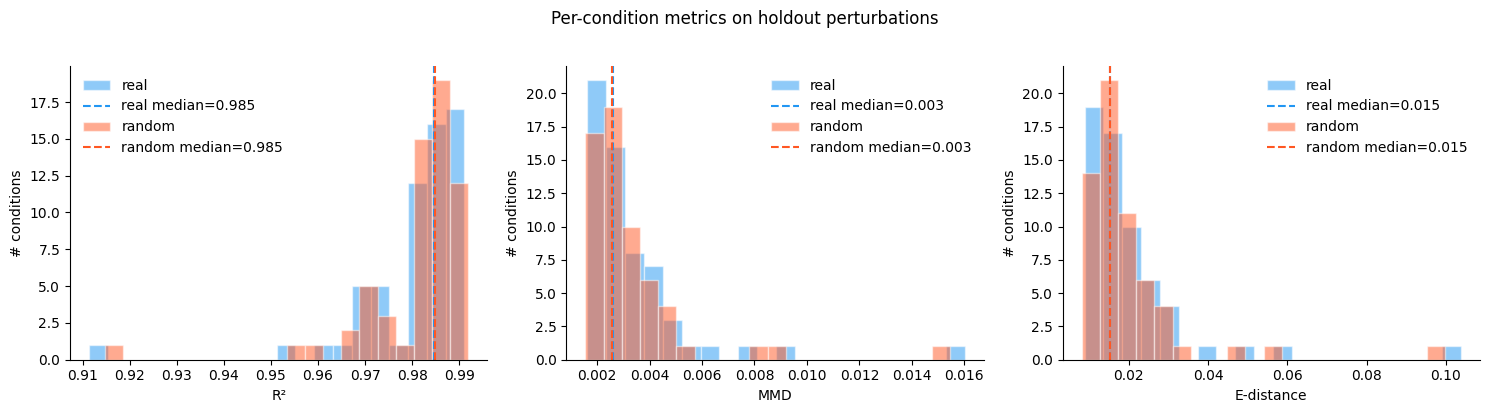

In [227]:
metrics = ["r_squared", "mmd", "e_distance"]
labels = ["R²", "MMD", "E-distance"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, metric, label in zip(axes, metrics, labels):
    for emb_type, color in [("real", "#2196F3"), ("random", "#FF5722")]:
        vals = df.loc[df["embeddings"] == emb_type, metric]
        ax.hist(vals, bins=20, alpha=0.5, label=emb_type, color=color, edgecolor="white")
        ax.axvline(vals.median(), color=color, linestyle="--", linewidth=1.5,
                   label=f"{emb_type} median={vals.median():.3f}")
    ax.set_xlabel(label)
    ax.set_ylabel("# conditions")
    ax.legend(frameon=False)
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle("Per-condition metrics on holdout perturbations", y=1.02)
fig.tight_layout()
plt.show()

## Embedding similarity vs effect similarity

Test whether **drug embedding similarity** correlates with **drug effect similarity** (MMD between target distributions). Two analyses:
1. **All pairs**: all condition pairs (same cell_line) from predictions.
2. **Holdout vs train**: only pairs where one drug is in training and one is held out.

In [ ]:
# Path to original Tahoe adata (with drug embeddings). Use same path as in train_and_predict.py.
ORIGINAL_ADATA_PATH = Path("/lustre/groups/ml01/workspace/xiaotong.fu/data/pancellflow/unipert/tahoe_a549_w_se.h5ad")

def embedding_vs_effect_similarity(adata_pred, adata_orig, in_train_per_drug=None):
    """Compute embedding distance and effect distance (MMD) for pairs of conditions (same cell_line)."""
    from scaleflow.metrics._metrics import compute_scalar_mmd
    emb_key = "drug_0_embeddings"
    if emb_key not in adata_orig.uns:
        raise KeyError(f"Original adata must have uns['{emb_key}']")
    emb_dict = adata_orig.uns[emb_key]

    def emb_vec(drug):
        return np.asarray(emb_dict.get(drug, np.nan)).ravel()
    def emb_dist(d1, d2):
        v1, v2 = emb_vec(d1), emb_vec(d2)
        if np.any(np.isnan(v1)) or np.any(np.isnan(v2)):
            return np.nan
        return float(np.linalg.norm(v1 - v2))

    groups = adata_pred.obs.groupby(["drug_0", "cell_line"], observed=True)
    condition_keys = list(groups.indices.keys())
    # Target arrays per (drug_0, cell_line)
    tgt_arrays = {}
    for (drug, cell_line) in condition_keys:
        mask = (adata_pred.obs["drug_0"] == drug) & (adata_pred.obs["cell_line"] == cell_line) & (adata_pred.obs["split"] == "target")
        if mask.sum() == 0:
            continue
        tgt_arrays[(drug, cell_line)] = np.asarray(adata_pred[mask].X)

    rows = []
    cell_lines = list(set(c for _, c in tgt_arrays.keys()))
    for cell_line in cell_lines:
        drugs = [d for (d, c) in tgt_arrays.keys() if c == cell_line]
        for i in range(len(drugs)):
            for j in range(i + 1, len(drugs)):
                d1, d2 = drugs[i], drugs[j]
                e_dist = emb_dist(d1, d2)
                if np.isnan(e_dist):
                    continue
                t1 = tgt_arrays[(d1, cell_line)]
                t2 = tgt_arrays[(d2, cell_line)]
                effect_dist = float(compute_scalar_mmd(t1, t2))
                in_train_1 = in_train_per_drug.get(d1, None) if in_train_per_drug else None
                in_train_2 = in_train_per_drug.get(d2, None) if in_train_per_drug else None
                holdout_train_pair = (in_train_1 is not None and in_train_2 is not None and in_train_1 != in_train_2)
                rows.append({
                    "drug_1": d1, "drug_2": d2, "cell_line": cell_line,
                    "embedding_dist": e_dist, "effect_dist_mmd": effect_dist,
                    "holdout_train_pair": holdout_train_pair,
                })
    return pd.DataFrame(rows)

# Build in_train set from predictions (first occurrence per drug)
_in_train = {}
for _, row in adata_real.obs.drop_duplicates("drug_0").iterrows():
    _in_train[row["drug_0"]] = bool(row.get("in_train", False))
df_emb_eff = embedding_vs_effect_similarity(adata_real, sc.read_h5ad(ORIGINAL_ADATA_PATH), in_train_per_drug=_in_train)
df_emb_eff.head(10)

In [ ]:
from scipy.stats import pearsonr, spearmanr

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# All pairs
df_all = df_emb_eff
ax = axes[0]
ax.scatter(df_all["embedding_dist"], df_all["effect_dist_mmd"], alpha=0.4, s=15)
r_p, p_p = pearsonr(df_all["embedding_dist"], df_all["effect_dist_mmd"])
r_s, p_s = spearmanr(df_all["embedding_dist"], df_all["effect_dist_mmd"])
ax.set_xlabel("Drug embedding distance (L2)")
ax.set_ylabel("Effect distance (MMD between targets)")
ax.set_title(f"All pairs (n={len(df_all)})\nPearson r={r_p:.3f} (p={p_p:.2e}), Spearman ρ={r_s:.3f} (p={p_s:.2e})")
ax.spines[["top", "right"]].set_visible(False)

# Holdout vs train only
df_ht = df_emb_eff[df_emb_eff["holdout_train_pair"]]
ax = axes[1]
if len(df_ht) > 0:
    ax.scatter(df_ht["embedding_dist"], df_ht["effect_dist_mmd"], alpha=0.6, s=25)
    r_p, p_p = pearsonr(df_ht["embedding_dist"], df_ht["effect_dist_mmd"])
    r_s, p_s = spearmanr(df_ht["embedding_dist"], df_ht["effect_dist_mmd"])
    ax.set_title(f"Holdout–train pairs only (n={len(df_ht)})\nPearson r={r_p:.3f} (p={p_p:.2e}), Spearman ρ={r_s:.3f} (p={p_s:.2e})")
else:
    ax.set_title("Holdout–train pairs only (n=0)")
ax.set_xlabel("Drug embedding distance (L2)")
ax.set_ylabel("Effect distance (MMD between targets)")
ax.spines[["top", "right"]].set_visible(False)
fig.suptitle("Embedding similarity vs effect similarity", y=1.02)
plt.tight_layout()
plt.show()

## MMD vs control MMD along training

Requires training with `--save-all-checkpoints` and `--checkpoint-steps`. Loads `mmd_along_training.csv` from the same output dir as predictions and plots:
- **Per condition**: MMD(pred, target) and MMD(pred, control) across checkpoint steps.
- **Sum / mean**: aggregate over conditions per step.
- **Scatter**: MMD vs control MMD at each checkpoint (to see if conditions are optimized equally).

In [ ]:
# Path to output dir that contains mmd_along_training.csv (same parent as predictions)
OUTPUT_DIR = REAL_PATH.parent  # or set explicitly, e.g. Path("./outputs/predictions")
MMD_CSV = OUTPUT_DIR / "mmd_along_training.csv"

if not MMD_CSV.exists():
    print(f"Not found: {MMD_CSV}. Run train_and_predict.py with --save-all-checkpoints and --checkpoint-steps.")
else:
    mmd_along = pd.read_csv(MMD_CSV)
    steps = sorted(mmd_along["checkpoint_step"].unique())
    print(f"Loaded {len(mmd_along)} rows, checkpoint steps: {steps}")

In [ ]:
if MMD_CSV.exists():
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))

    # 1) Per-condition MMD and control MMD over steps (faded lines + mean)
    ax = axes[0, 0]
    for key, grp in mmd_along.groupby("condition_key"):
        ax.plot(grp["checkpoint_step"], grp["mmd_pred_tgt"], color="C0", alpha=0.2, linewidth=0.8)
    mean_mmd = mmd_along.groupby("checkpoint_step")["mmd_pred_tgt"].mean()
    ax.plot(mean_mmd.index, mean_mmd.values, color="C0", linewidth=2, label="Mean MMD(pred,tgt)")
    ax.set_xlabel("Checkpoint step")
    ax.set_ylabel("MMD(pred, target)")
    ax.legend()
    ax.spines[["top", "right"]].set_visible(False)
    ax.set_title("MMD(pred, target) per condition along training")

    ax = axes[0, 1]
    for key, grp in mmd_along.groupby("condition_key"):
        ax.plot(grp["checkpoint_step"], grp["mmd_pred_control"], color="C1", alpha=0.2, linewidth=0.8)
    mean_ctrl = mmd_along.groupby("checkpoint_step")["mmd_pred_control"].mean()
    ax.plot(mean_ctrl.index, mean_ctrl.values, color="C1", linewidth=2, label="Mean MMD(pred,control)")
    ax.set_xlabel("Checkpoint step")
    ax.set_ylabel("MMD(pred, control)")
    ax.legend()
    ax.spines[["top", "right"]].set_visible(False)
    ax.set_title("MMD(pred, control) per condition along training")

    # 2) Sum of MMD and sum of control MMD over steps
    ax = axes[1, 0]
    sum_mmd = mmd_along.groupby("checkpoint_step")["mmd_pred_tgt"].sum()
    sum_ctrl = mmd_along.groupby("checkpoint_step")["mmd_pred_control"].sum()
    ax.plot(sum_mmd.index, sum_mmd.values, "o-", label="Sum MMD(pred,tgt)")
    ax.plot(sum_ctrl.index, sum_ctrl.values, "s-", label="Sum MMD(pred,control)")
    ax.set_xlabel("Checkpoint step")
    ax.set_ylabel("Sum over conditions")
    ax.legend()
    ax.spines[["top", "right"]].set_visible(False)
    ax.set_title("Sum of MMD and control MMD per step")

    # 3) Scatter: MMD vs control MMD at each step (one point per condition)
    ax = axes[1, 1]
    for step in steps:
        sub = mmd_along[mmd_along["checkpoint_step"] == step]
        ax.scatter(sub["mmd_pred_control"], sub["mmd_pred_tgt"], alpha=0.5, s=20, label=f"Step {step}")
    ax.set_xlabel("MMD(pred, control)")
    ax.set_ylabel("MMD(pred, target)")
    ax.legend(bbox_to_anchor=(1.02, 1), fontsize=8)
    ax.spines[["top", "right"]].set_visible(False)
    ax.set_title("MMD vs control MMD per condition (by step)")

    fig.suptitle("MMD and control MMD along training", y=1.02)
    plt.tight_layout()
    plt.show()

In [12]:
df[df.drug_0 == 'Acetazolamide']

,drug_0,cell_line,r_squared,mmd,e_distance,n_pred,n_target,embeddings
0,Acetazolamide,CVCL_0023,0.986333,0.002281,0.013314,57448,5434,real
60,Acetazolamide,CVCL_0023,0.987638,0.002098,0.012040,57448,5434,random


In [20]:
adata_random.obs.drug_0.unique()

['Acetazolamide', 'Aliskiren', 'Allopurinol', 'Alpelisib', 'Anastrozole', ..., 'Sodium Salicylate', 'Sunitinib', 'Tomivosertib', 'Tucatinib', 'Valdecoxib']
Length: 60
Categories (60, object): ['Acetazolamide', 'Aliskiren', 'Allopurinol', 'Alpelisib', ..., 'Sunitinib', 'Tomivosertib', 'Tucatinib', 'Valdecoxib']

In [23]:
import pertpy as pt
import scanpy as sc

In [25]:
adata_random.obs

,drug_0,cell_line,split
0,Acetazolamide,CVCL_0023,prediction
1,Acetazolamide,CVCL_0023,prediction
2,Acetazolamide,CVCL_0023,prediction
3,Acetazolamide,CVCL_0023,prediction
4,Acetazolamide,CVCL_0023,prediction
...,...,...,...
7272967,Valdecoxib,CVCL_0023,source
7272968,Valdecoxib,CVCL_0023,source
7272969,Valdecoxib,CVCL_0023,source
7272970,Valdecoxib,CVCL_0023,source


In [28]:
adata_random[adata_random.obs.drug_0 == 'Acetazolamide'].obs

,drug_0,cell_line,split
0,Acetazolamide,CVCL_0023,prediction
1,Acetazolamide,CVCL_0023,prediction
2,Acetazolamide,CVCL_0023,prediction
3,Acetazolamide,CVCL_0023,prediction
4,Acetazolamide,CVCL_0023,prediction
...,...,...,...
120325,Acetazolamide,CVCL_0023,source
120326,Acetazolamide,CVCL_0023,source
120327,Acetazolamide,CVCL_0023,source
120328,Acetazolamide,CVCL_0023,source


In [29]:
ps = pt.tl.PseudobulkSpace()
psadata = ps.compute(
    adata_random[adata_random.obs.split == 'prediction'],
    target_col="drug_0",
    mode="mean",
)

/ictstr01/groups/ml01/workspace/alejandro.tejada/micromamba/envs/scaleflow/lib/python3.12/site-packages/pertpy/tools/_perturbation_space/_simple.py:164: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs[target_col] = adata.obs[target_col].astype("category")


In [ ]:
sc.pp.neighbors(psadata)
sc.tl.umap(psadata)

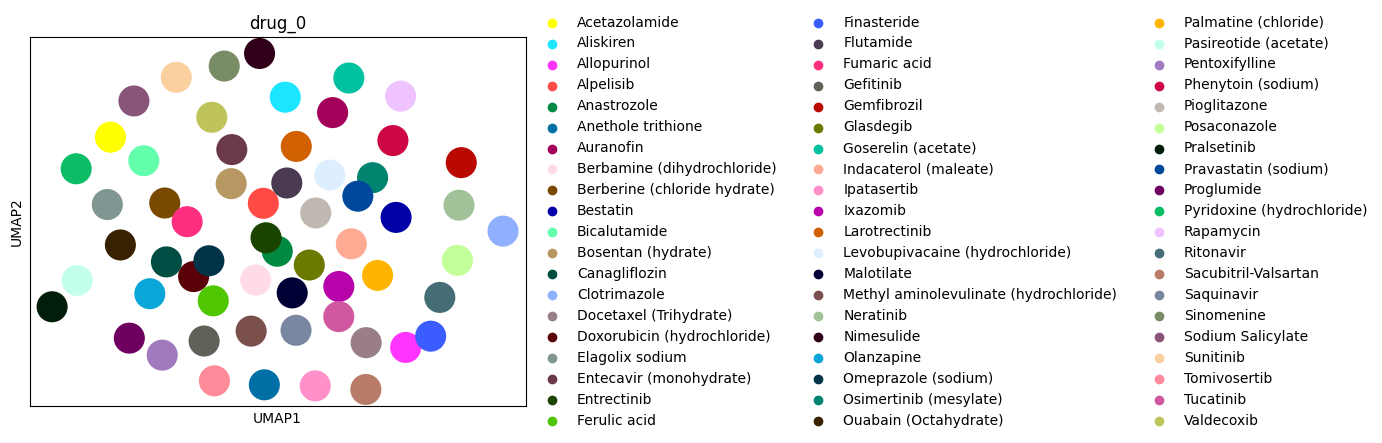

In [31]:
sc.pl.umap(psadata, color="drug_0")

In [36]:
ps = pt.tl.PseudobulkSpace()
psadata = ps.compute(
    adata_real[adata_real.obs.split == 'prediction'],
    target_col="drug_0",
    mode="mean",
)

/ictstr01/groups/ml01/workspace/alejandro.tejada/micromamba/envs/scaleflow/lib/python3.12/site-packages/pertpy/tools/_perturbation_space/_simple.py:164: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs[target_col] = adata.obs[target_col].astype("category")


In [37]:
sc.pp.neighbors(psadata)
sc.tl.umap(psadata)

/tmp/ipykernel_2239486/3118158569.py:1: UserWarning: You’re trying to run this on 2058 dimensions of `.X`, if you really want this, set `use_rep='X'`.
         Falling back to preprocessing with `sc.pp.pca` and default params.
  sc.pp.neighbors(psadata)


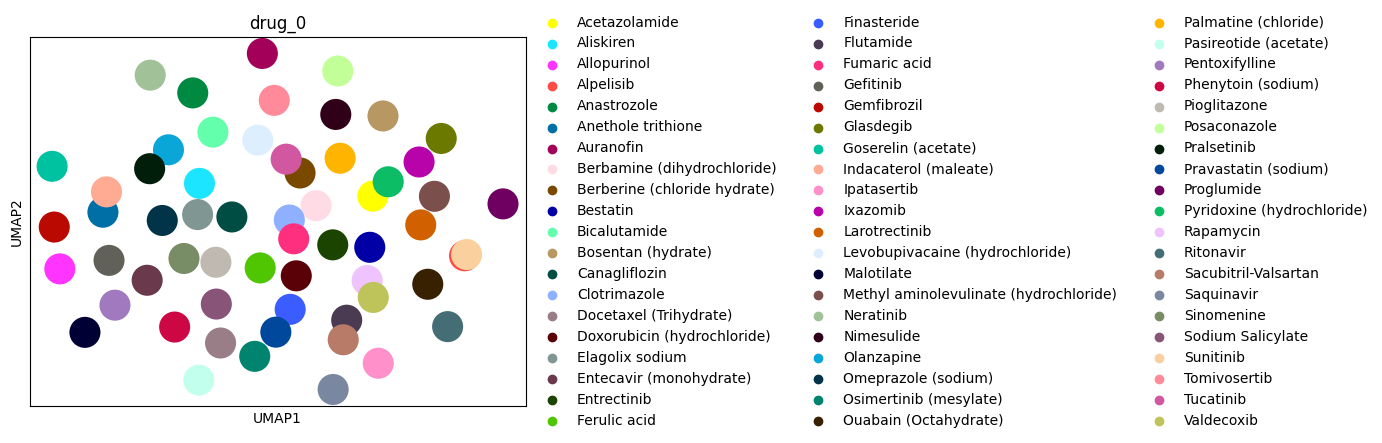

In [38]:
sc.pl.umap(psadata, color="drug_0")

In [35]:
adata_real.obs

,drug_0,cell_line,split
0,Acetazolamide,CVCL_0023,prediction
1,Acetazolamide,CVCL_0023,prediction
2,Acetazolamide,CVCL_0023,prediction
3,Acetazolamide,CVCL_0023,prediction
4,Acetazolamide,CVCL_0023,prediction
...,...,...,...
7272967,Valdecoxib,CVCL_0023,source
7272968,Valdecoxib,CVCL_0023,source
7272969,Valdecoxib,CVCL_0023,source
7272970,Valdecoxib,CVCL_0023,source


/ictstr01/groups/ml01/workspace/alejandro.tejada/micromamba/envs/scaleflow/lib/python3.12/site-packages/pertpy/tools/_perturbation_space/_simple.py:164: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs[target_col] = adata.obs[target_col].astype("category")
/tmp/ipykernel_2239486/3858314111.py:7: UserWarning: You’re trying to run this on 2058 dimensions of `.X`, if you really want this, set `use_rep='X'`.
         Falling back to preprocessing with `sc.pp.pca` and default params.
  sc.pp.neighbors(psadata)


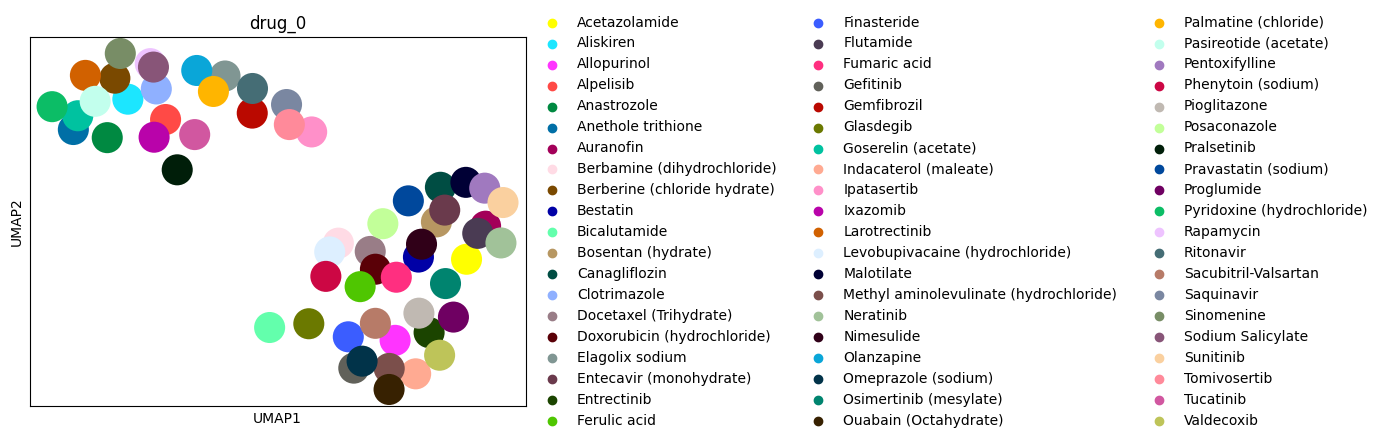

In [40]:
ps = pt.tl.PseudobulkSpace()
psadata = ps.compute(
    adata_real[adata_real.obs.split == 'target'],
    target_col="drug_0",
    mode="mean",
)
sc.pp.neighbors(psadata)
sc.tl.umap(psadata)

sc.pl.umap(psadata, color="drug_0")

Are results correlated with distance from control?

In [86]:
import json

#file_path = '/home/icb/alejandro.tejada/CellFlow2/baseline_metrics_unipert_seed42.json'
file_path = '/home/icb/alejandro.tejada/CellFlow2/baseline_metrics.json'

with open(file_path) as f:
    data = json.load(f)

rows = []
for key, metrics in data["per_condition"].items():
    drug, baseline = key.rsplit("+", 1)
    for metric in ("mmd", "e_distance", "r_squared"):
        rows.append({"drug": drug, "baseline": baseline, "metric": metric, "value": metrics[metric]})

df = (
    pd.DataFrame(rows)
    .assign(col=lambda x: x["baseline"] + "_" + x["metric"])
    .pivot(index="drug", columns="col", values="value")
)
df.columns.name = None

In [88]:
df['drug_0'] = df.index

In [89]:
df

,control_e_distance,control_mmd,control_r_squared,drug_0
drug,,,,
(R)-Verapamil (hydrochloride),0.009976,0.001696,0.989923,(R)-Verapamil (hydrochloride)
(S)-Crizotinib,0.015973,0.002757,0.983865,(S)-Crizotinib
4EGI-1,0.045020,0.007636,0.954523,4EGI-1
5-Azacytidine,0.015559,0.002730,0.984283,5-Azacytidine
5-Fluorouracil,0.019780,0.003308,0.980019,5-Fluorouracil
...,...,...,...,...
crizotinib,0.030315,0.005052,0.969378,crizotinib
olaparib,0.029204,0.005061,0.970500,olaparib
palbociclib,0.019989,0.003528,0.979808,palbociclib


In [204]:
df_computed = pd.concat([df_real, df_random], ignore_index=True)
df_computed.head()

,drug_0,cell_line,r_squared,mmd,e_distance,n_pred,n_target,embeddings
0,Acetazolamide,CVCL_0023,0.985200,0.002440,0.014416,57448,5434,real
1,Aliskiren,CVCL_0023,0.988398,0.002136,0.012419,57448,6365,real
2,Allopurinol,CVCL_0023,0.981697,0.003242,0.019803,57448,8694,real
3,Alpelisib,CVCL_0023,0.979053,0.003454,0.021583,57448,4908,real
4,Anastrozole,CVCL_0023,0.946806,0.009600,0.061697,57448,8281,real


In [11]:
df_computed.drug_0.unique().shape

NameError: name 'df_computed' is not defined

In [42]:
df.index.values.shape

(60,)

In [76]:
df['drug_0'] = df.index.str.split('+').str[0]

In [44]:
df.drug_0.values

array(['Acetazolamide', 'Aliskiren', 'Allopurinol', 'Alpelisib',
       'Altretamine', 'Anastrozole', 'Apalutamide',
       'Azithromycin (hydrate)', 'Berbamine (dihydrochloride)',
       'Berberine (chloride hydrate)', 'Bestatin (hydrochloride)',
       'Bicalutamide', 'Bosentan (hydrate)',
       'Canagliflozin (hemihydrate)', 'Cobimetinib', 'Docetaxel',
       'Doxorubicin (hydrochloride)', 'Edoxaban (tosylate monohydrate)',
       'Encorafenib', 'Entecavir (monohydrate)', 'Entrectinib',
       'Filgotinib', 'Fingolimod (hydrochloride)', 'Fluvoxamine',
       'Fumaric acid', 'Gefitinib', 'Gemfibrozil', 'Glasdegib',
       'Glycyrrhizic acid', 'Imiquimod (hydrochloride)', 'Infigratinib',
       'Ixazomib', 'Lapatinib ditosylate',
       'Levobupivacaine (hydrochloride)', 'Macitentan', 'Meloxicam',
       'NVP-BHG712', 'Neratinib (maleate)',
       'Norepinephrine (hydrochloride)', 'Olanzapine',
       'Omeprazole (sodium)', 'Orlistat', 'PF-06260933',
       'Palmatine (chloride)', 'P

In [45]:
allowed_drugs = df_real['drug_0'].unique()

# 3. Filter the main DataFrame
df_filtered = df[df['drug_0'].isin(allowed_drugs)]

In [46]:
df.drug_0.unique().shape

(60,)

In [47]:
df_filtered.drug_0.unique().shape

(60,)

In [48]:
df_real.drug_0.unique().shape

(60,)

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import linregress

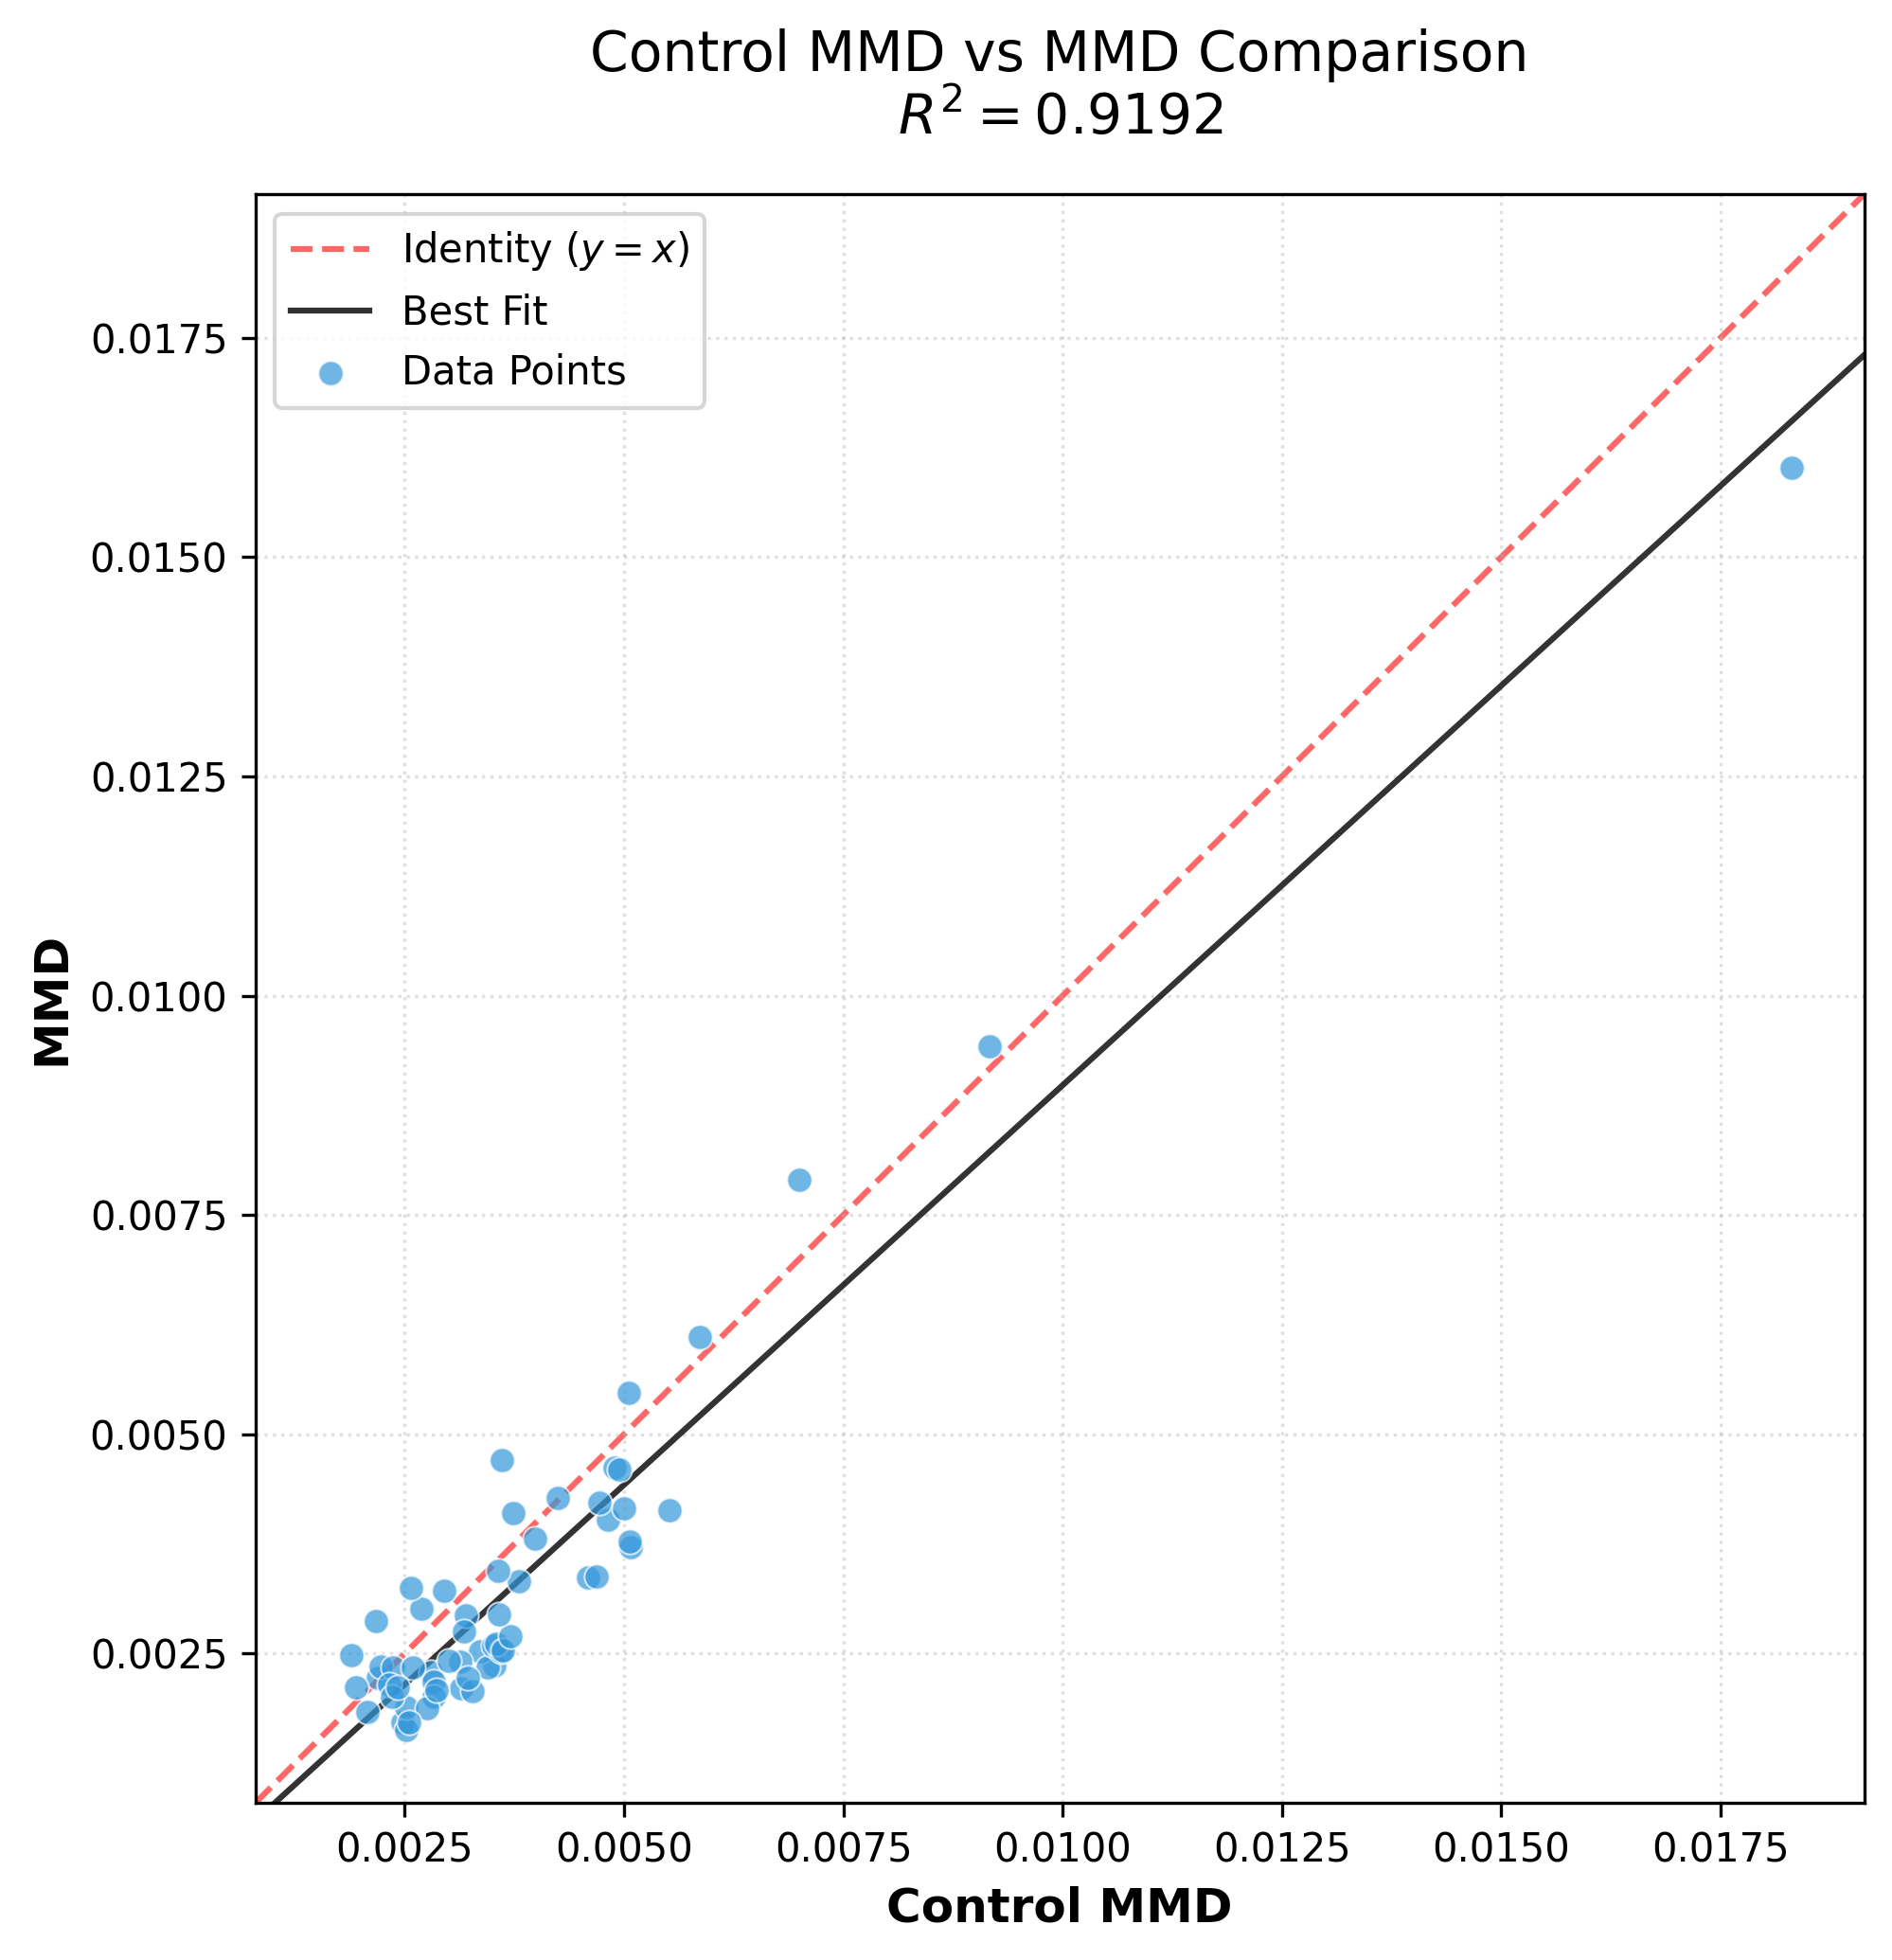

In [228]:
merged_df = pd.merge(df_filtered, df_real, on='drug_0')

x = merged_df['control_mmd']
y = merged_df['mmd']

# 2. Stats: R-squared and Regression line
slope, intercept, r_value, p_value, std_err = linregress(x, y)
r_squared = r_value**2

# 3. Calculate Limits with Padding
# Find the absolute min/max across both datasets for a square plot
data_min = min(x.min(), y.min())
data_max = max(x.max(), y.max())
data_range = data_max - data_min

padding = 0.05 * data_range  # 5% margin
plot_min = data_min - padding
plot_max = data_max + padding

# 4. Plotting
plt.figure(figsize=(7, 7), dpi=300)

# Identity Line (y=x) - Red, Dashed
plt.plot([plot_min, plot_max], [plot_min, plot_max], 
         color='red', linestyle='--', alpha=0.6, zorder=1, label='Identity ($y=x$)')

# Best Fit Line (Regression) - Black, Solid
reg_x = np.array([plot_min, plot_max])
reg_y = slope * reg_x + intercept
plt.plot(reg_x, reg_y, color='black', linewidth=1.5, alpha=0.8, zorder=2, label='Best Fit')

# Scatter Points
plt.scatter(x, y, s=40, alpha=0.7, edgecolors='white', linewidth=0.5, 
            color='#3498db', zorder=3, label='Data Points')

# 5. Apply the padded limits
plt.xlim(plot_min, plot_max)
plt.ylim(plot_min, plot_max)
plt.gca().set_aspect('equal', adjustable='box')

# Labels and Styling
plt.xlabel('Control MMD', fontsize=12, fontweight='bold')
plt.ylabel('MMD', fontsize=12, fontweight='bold')
plt.title(f'Control MMD vs MMD Comparison\n$R^2 = {r_squared:.4f}$', fontsize=14, pad=15)
plt.legend(loc='upper left', frameon=True, fontsize=10)
plt.grid(True, linestyle=':', alpha=0.4)

plt.tight_layout()

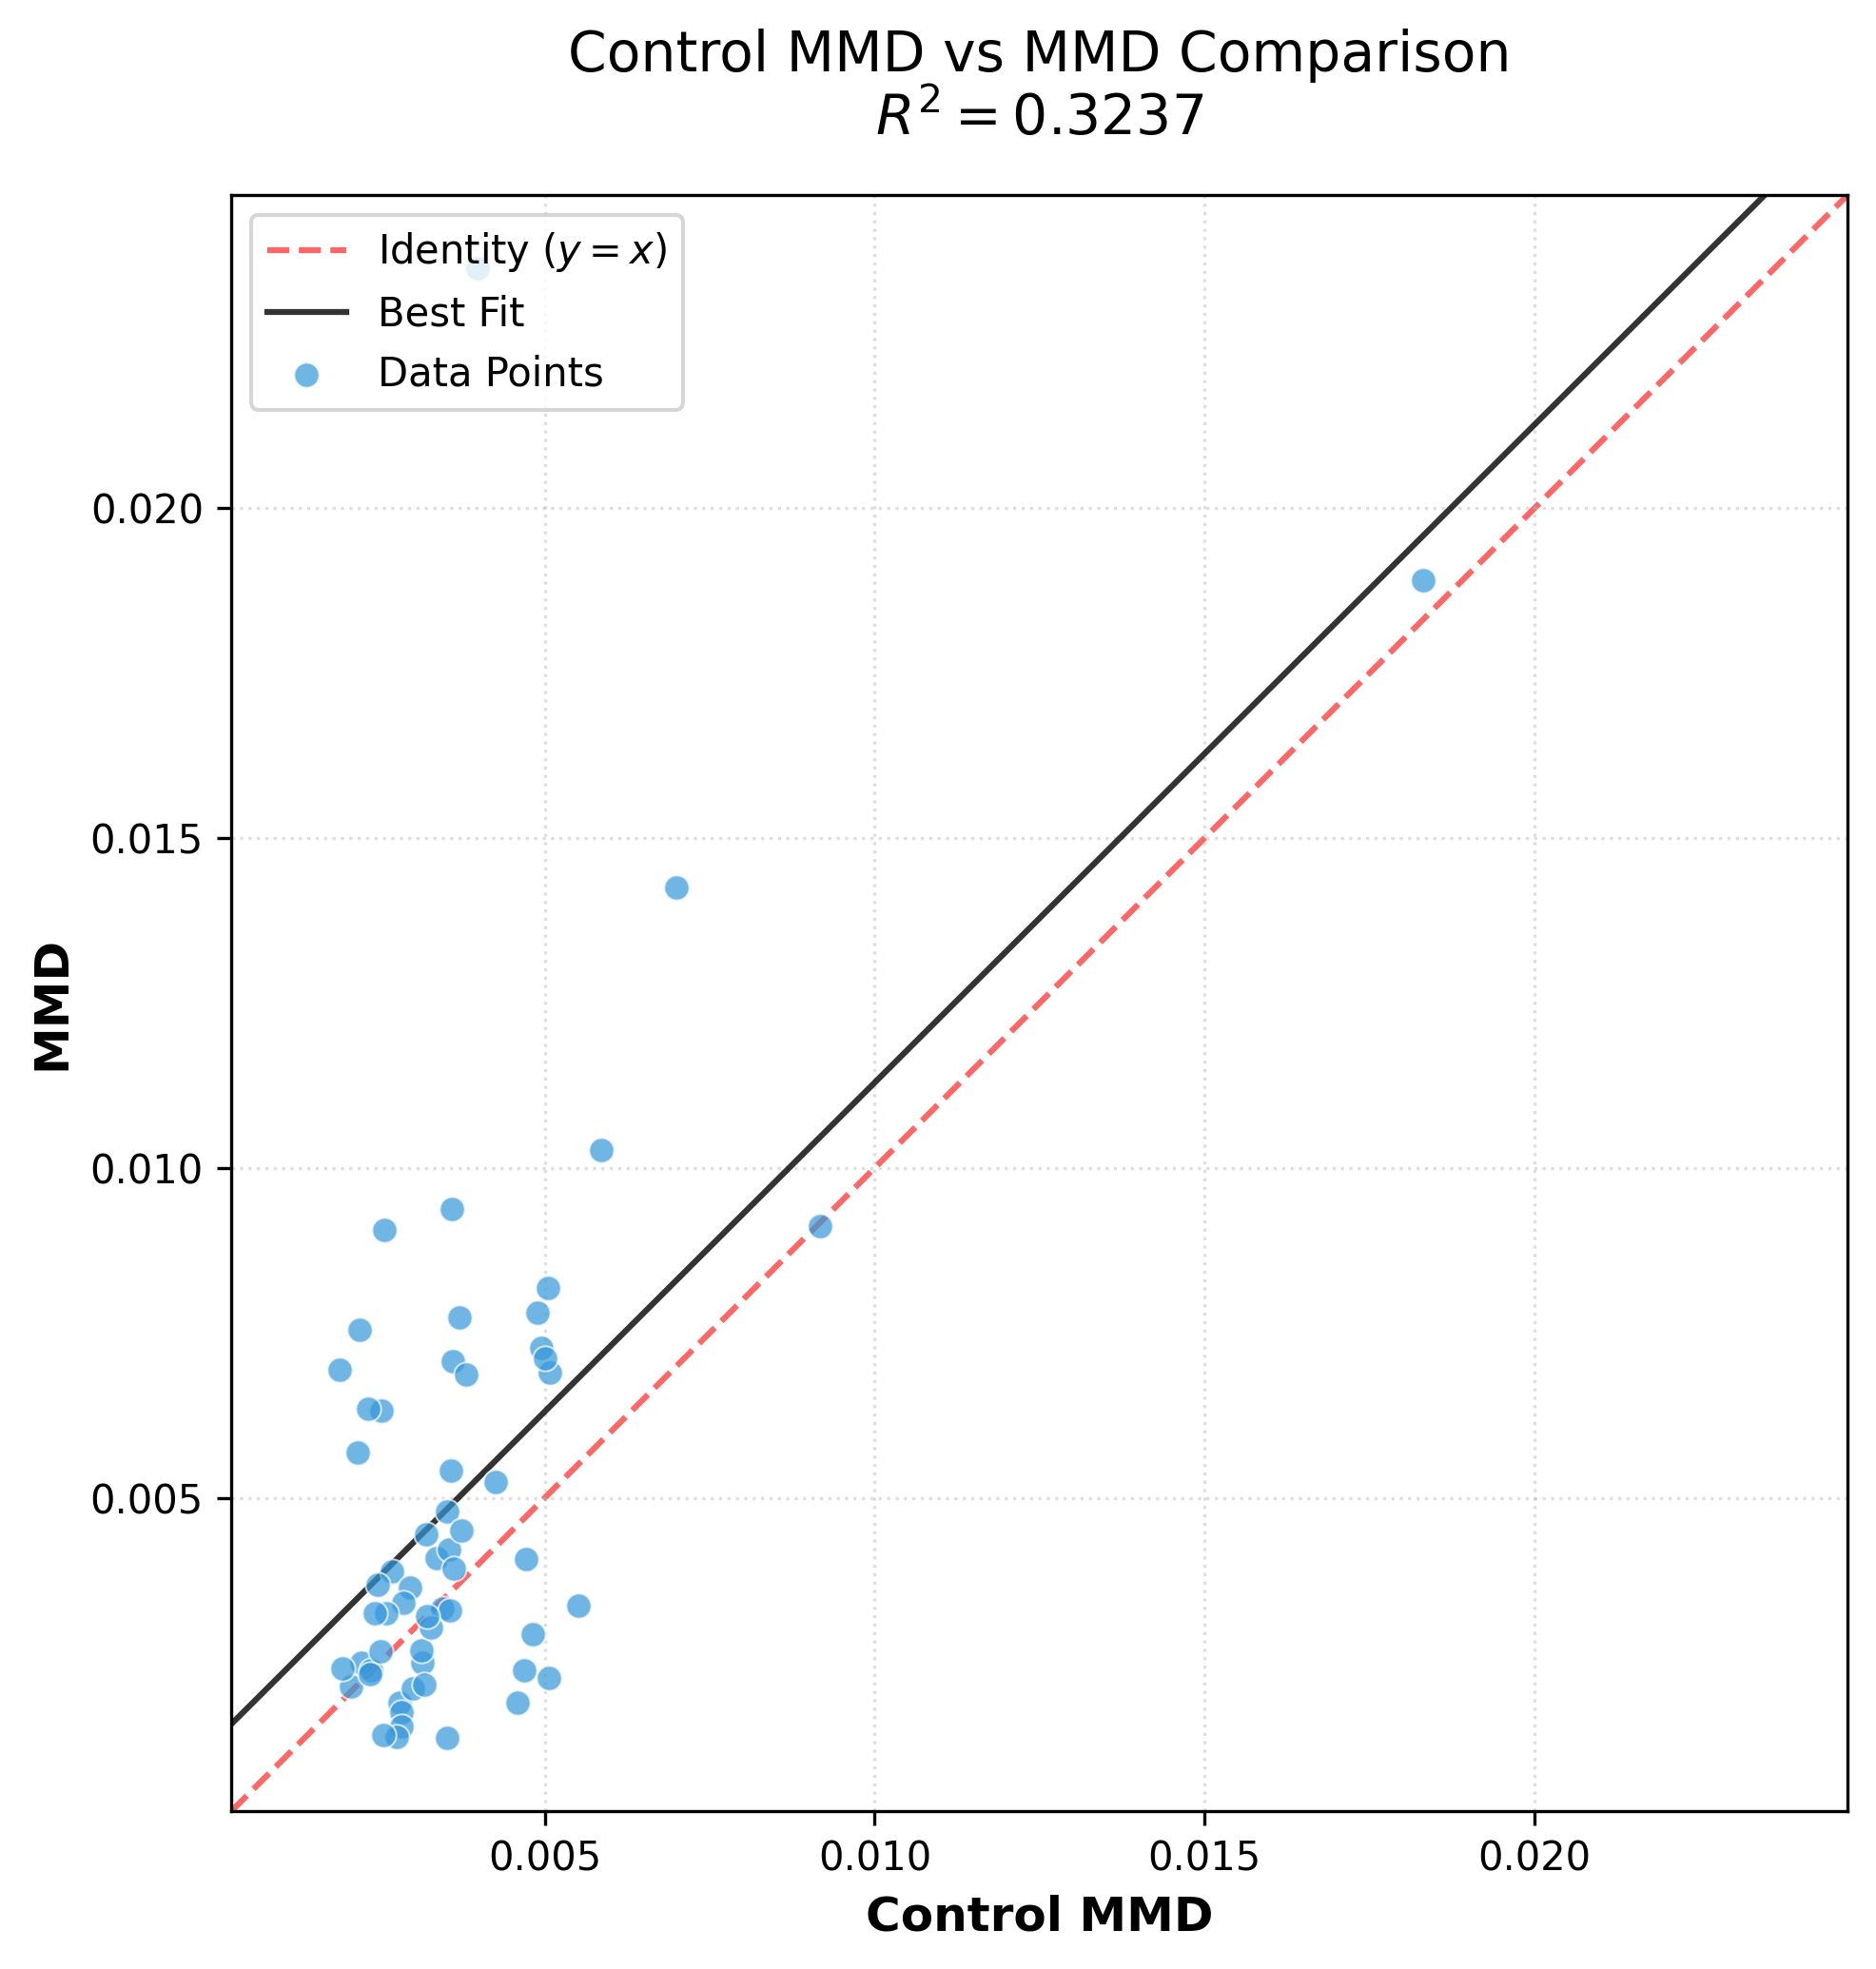

In [237]:
merged_df = pd.merge(df_filtered, df_real, on='drug_0')

x = merged_df['control_mmd']
y = merged_df['mmd']

# 2. Stats: R-squared and Regression line
slope, intercept, r_value, p_value, std_err = linregress(x, y)
r_squared = r_value**2

# 3. Calculate Limits with Padding
# Find the absolute min/max across both datasets for a square plot
data_min = min(x.min(), y.min())
data_max = max(x.max(), y.max())
data_range = data_max - data_min

padding = 0.05 * data_range  # 5% margin
plot_min = data_min - padding
plot_max = data_max + padding

# 4. Plotting
plt.figure(figsize=(7, 7), dpi=300)

# Identity Line (y=x) - Red, Dashed
plt.plot([plot_min, plot_max], [plot_min, plot_max], 
         color='red', linestyle='--', alpha=0.6, zorder=1, label='Identity ($y=x$)')

# Best Fit Line (Regression) - Black, Solid
reg_x = np.array([plot_min, plot_max])
reg_y = slope * reg_x + intercept
plt.plot(reg_x, reg_y, color='black', linewidth=1.5, alpha=0.8, zorder=2, label='Best Fit')

# Scatter Points
plt.scatter(x, y, s=40, alpha=0.7, edgecolors='white', linewidth=0.5, 
            color='#3498db', zorder=3, label='Data Points')

# 5. Apply the padded limits
plt.xlim(plot_min, plot_max)
plt.ylim(plot_min, plot_max)
plt.gca().set_aspect('equal', adjustable='box')

# Labels and Styling
plt.xlabel('Control MMD', fontsize=12, fontweight='bold')
plt.ylabel('MMD', fontsize=12, fontweight='bold')
plt.title(f'Control MMD vs MMD Comparison\n$R^2 = {r_squared:.4f}$', fontsize=14, pad=15)
plt.legend(loc='upper left', frameon=True, fontsize=10)
plt.grid(True, linestyle=':', alpha=0.4)

plt.tight_layout()

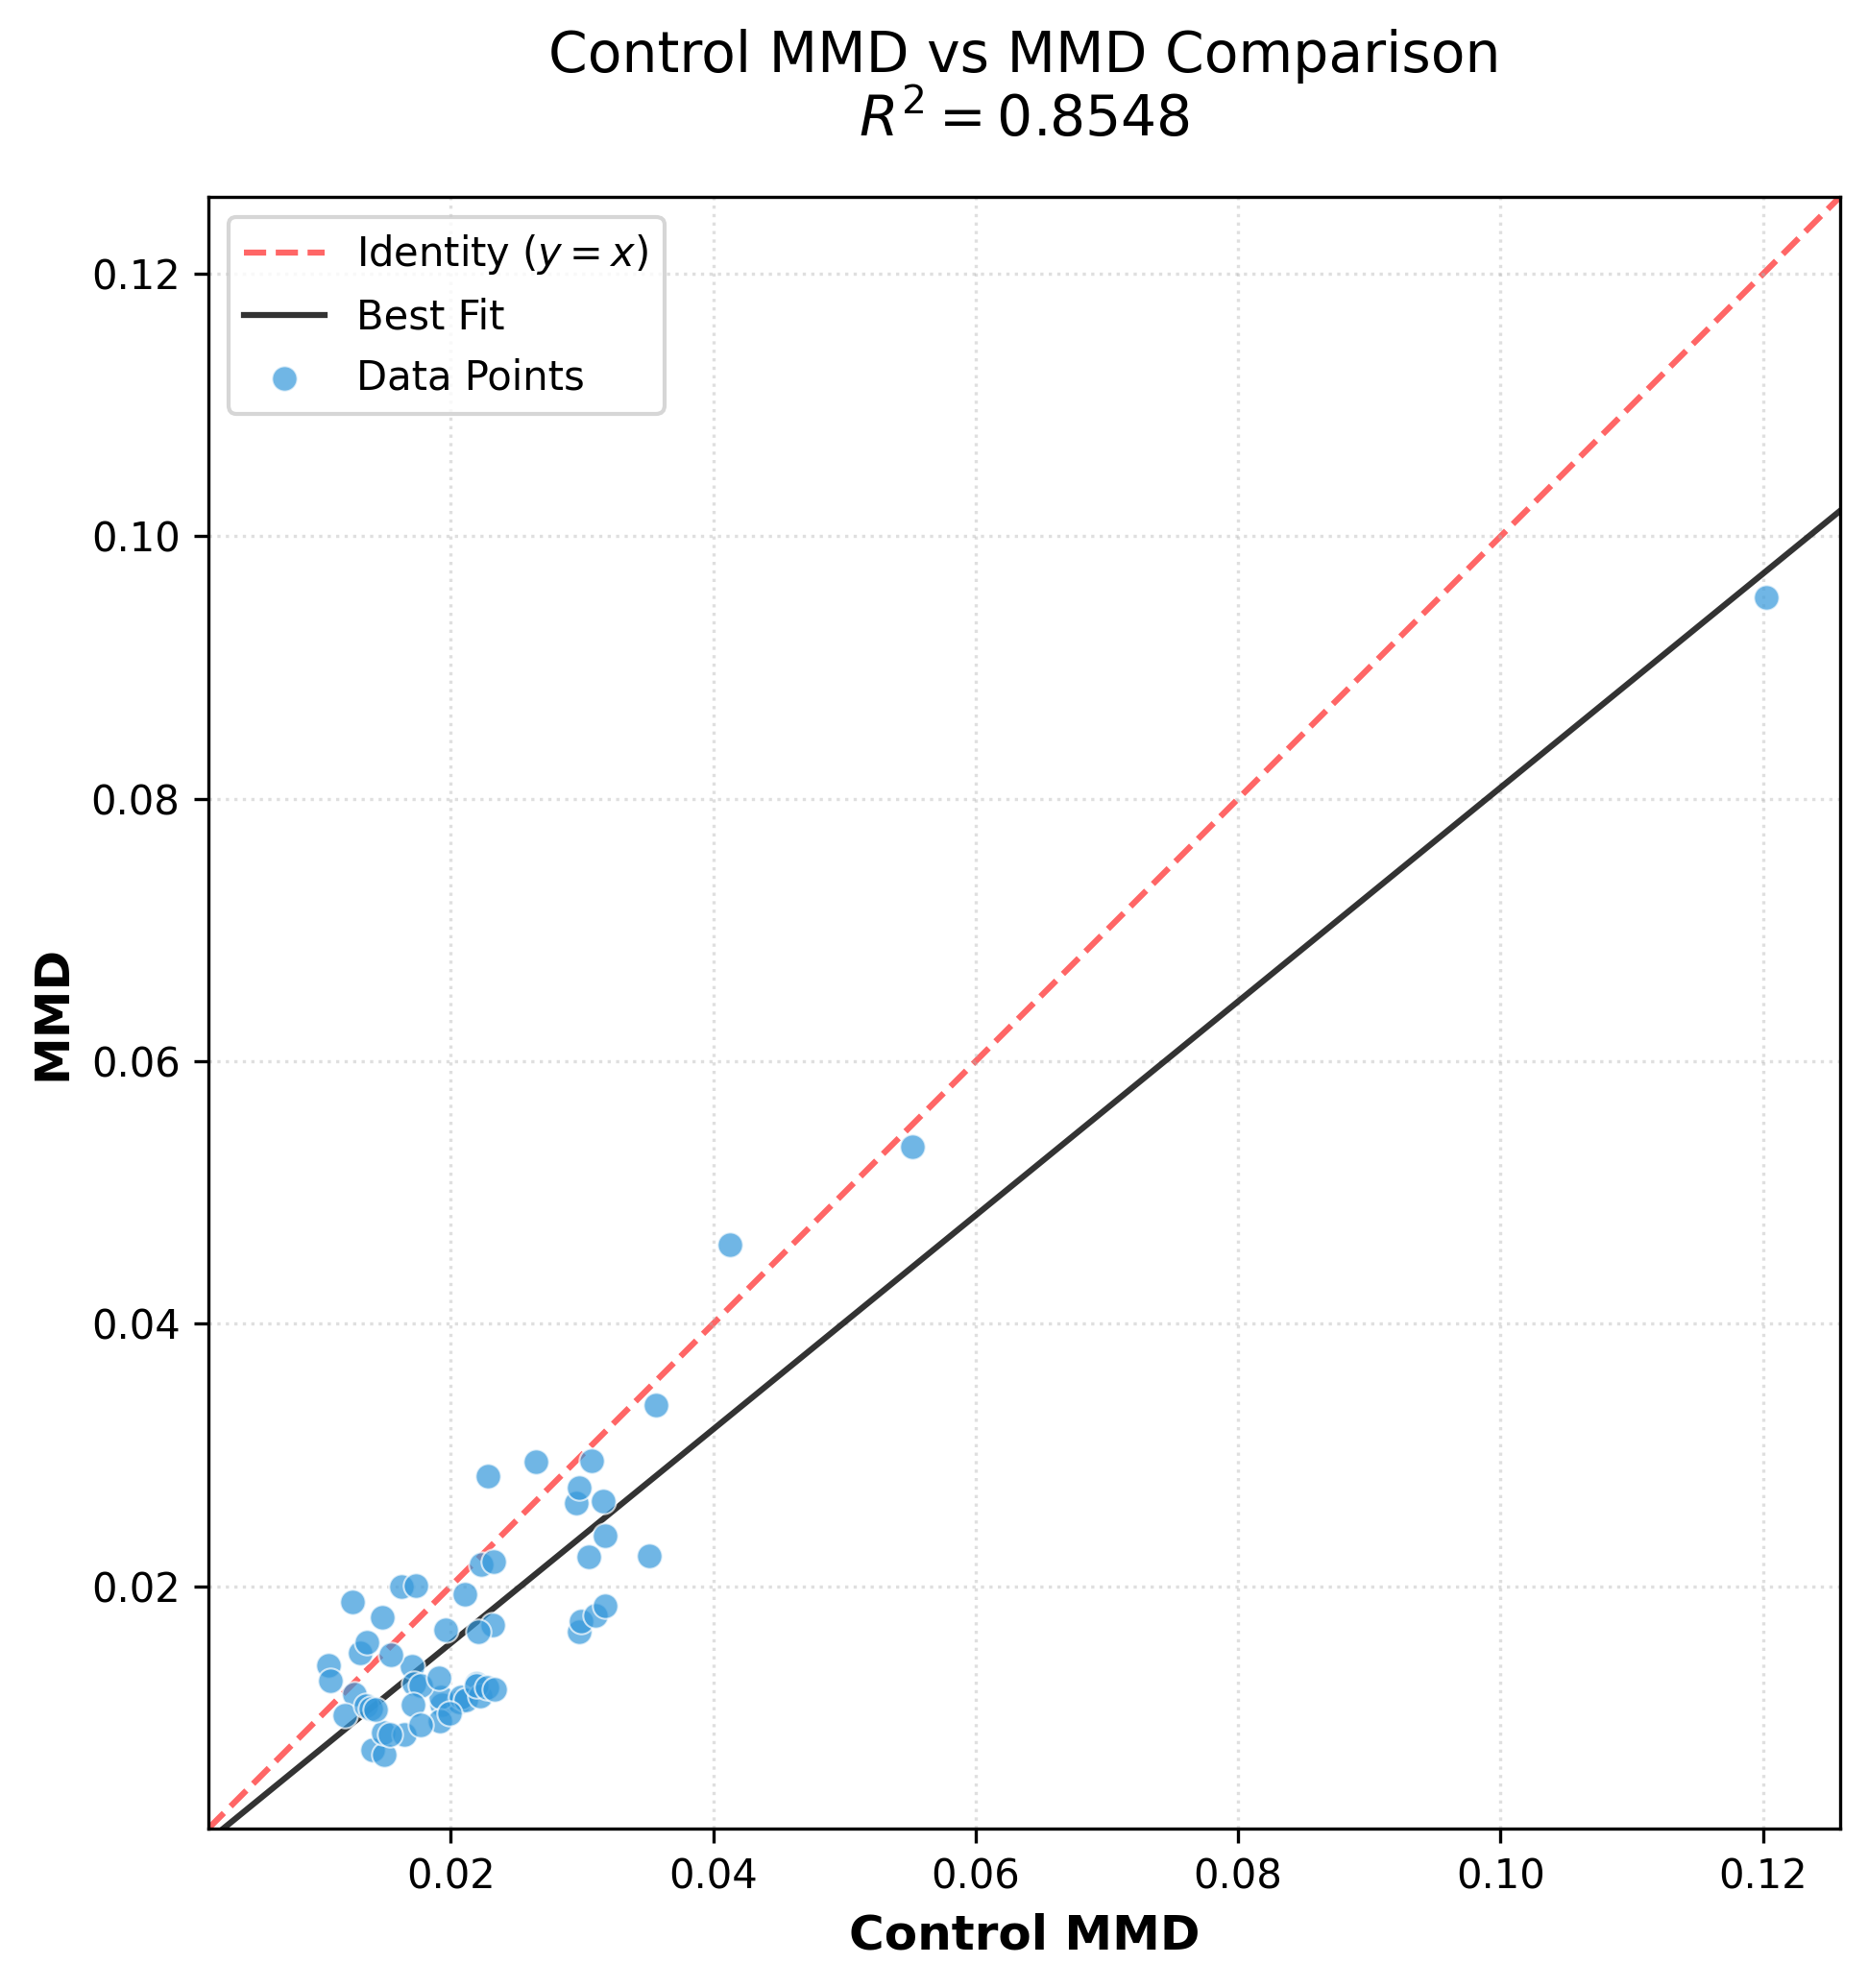

In [33]:
merged_df = pd.merge(df_filtered, df_real, on='drug_0')

x = merged_df['control_e_distance']
y = merged_df['e_distance']

# 2. Stats: R-squared and Regression line
slope, intercept, r_value, p_value, std_err = linregress(x, y)
r_squared = r_value**2

# 3. Calculate Limits with Padding
# Find the absolute min/max across both datasets for a square plot
data_min = min(x.min(), y.min())
data_max = max(x.max(), y.max())
data_range = data_max - data_min

padding = 0.05 * data_range  # 5% margin
plot_min = data_min - padding
plot_max = data_max + padding

# 4. Plotting
plt.figure(figsize=(7, 7), dpi=300)

# Identity Line (y=x) - Red, Dashed
plt.plot([plot_min, plot_max], [plot_min, plot_max], 
         color='red', linestyle='--', alpha=0.6, zorder=1, label='Identity ($y=x$)')

# Best Fit Line (Regression) - Black, Solid
reg_x = np.array([plot_min, plot_max])
reg_y = slope * reg_x + intercept
plt.plot(reg_x, reg_y, color='black', linewidth=1.5, alpha=0.8, zorder=2, label='Best Fit')

# Scatter Points
plt.scatter(x, y, s=40, alpha=0.7, edgecolors='white', linewidth=0.5, 
            color='#3498db', zorder=3, label='Data Points')

# 5. Apply the padded limits
plt.xlim(plot_min, plot_max)
plt.ylim(plot_min, plot_max)
plt.gca().set_aspect('equal', adjustable='box')

# Labels and Styling
plt.xlabel('Control MMD', fontsize=12, fontweight='bold')
plt.ylabel('MMD', fontsize=12, fontweight='bold')
plt.title(f'Control MMD vs MMD Comparison\n$R^2 = {r_squared:.4f}$', fontsize=14, pad=15)
plt.legend(loc='upper left', frameon=True, fontsize=10)
plt.grid(True, linestyle=':', alpha=0.4)

plt.tight_layout()

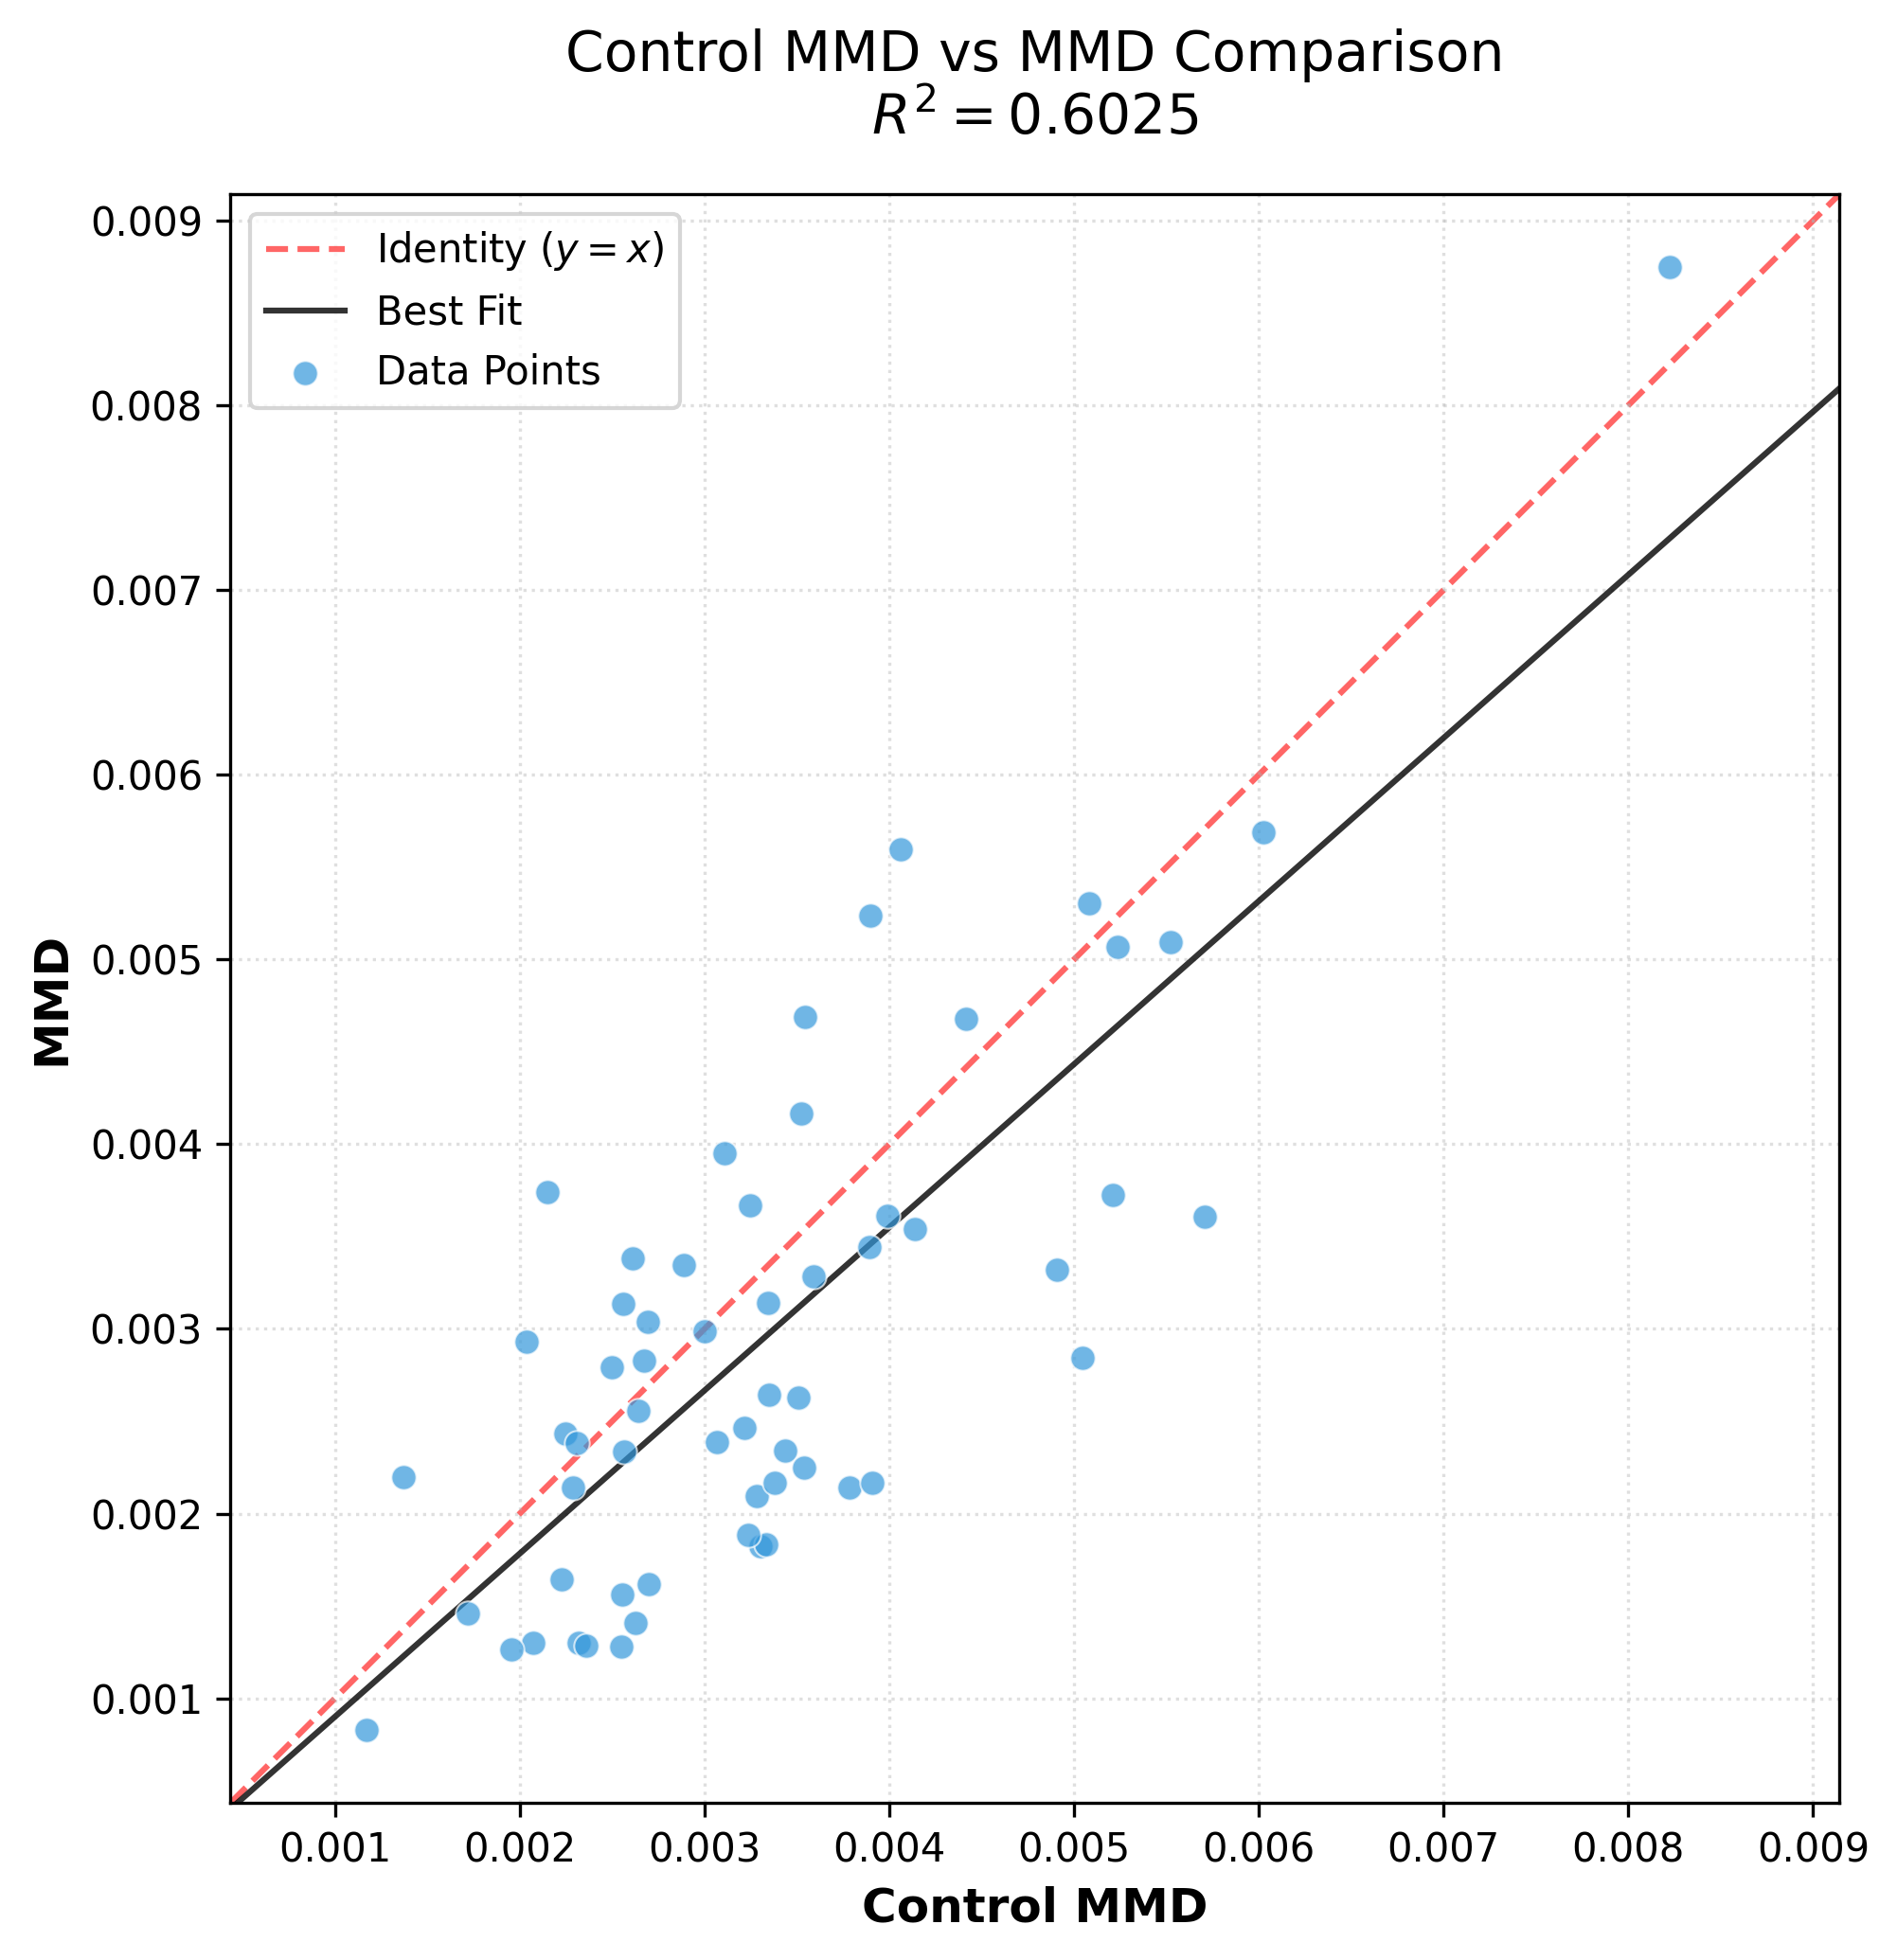

In [50]:
merged_df = pd.merge(df_filtered, df_real, on='drug_0')

x = merged_df['control_mmd']
y = merged_df['mmd']

# 2. Stats: R-squared and Regression line
slope, intercept, r_value, p_value, std_err = linregress(x, y)
r_squared = r_value**2

# 3. Calculate Limits with Padding
# Find the absolute min/max across both datasets for a square plot
data_min = min(x.min(), y.min())
data_max = max(x.max(), y.max())
data_range = data_max - data_min

padding = 0.05 * data_range  # 5% margin
plot_min = data_min - padding
plot_max = data_max + padding

# 4. Plotting
plt.figure(figsize=(5, 5), dpi=300)

# Identity Line (y=x) - Red, Dashed
plt.plot([plot_min, plot_max], [plot_min, plot_max], 
         color='red', linestyle='--', alpha=0.6, zorder=1, label='Identity ($y=x$)')

# Best Fit Line (Regression) - Black, Solid
reg_x = np.array([plot_min, plot_max])
reg_y = slope * reg_x + intercept
plt.plot(reg_x, reg_y, color='black', linewidth=1.5, alpha=0.8, zorder=2, label='Best Fit')

# Scatter Points
plt.scatter(x, y, s=40, alpha=0.7, edgecolors='white', linewidth=0.5, 
            color='#3498db', zorder=3, label='Data Points')

# 5. Apply the padded limits
plt.xlim(plot_min, plot_max)
plt.ylim(plot_min, plot_max)
plt.gca().set_aspect('equal', adjustable='box')

# Labels and Styling
plt.xlabel('Control MMD', fontsize=12, fontweight='bold')
plt.ylabel('MMD', fontsize=12, fontweight='bold')
plt.title(f'Control MMD vs MMD Comparison\n$R^2 = {r_squared:.4f}$', fontsize=14, pad=15)
plt.legend(loc='upper left', frameon=True, fontsize=10)
plt.grid(True, linestyle=':', alpha=0.4)

plt.tight_layout()

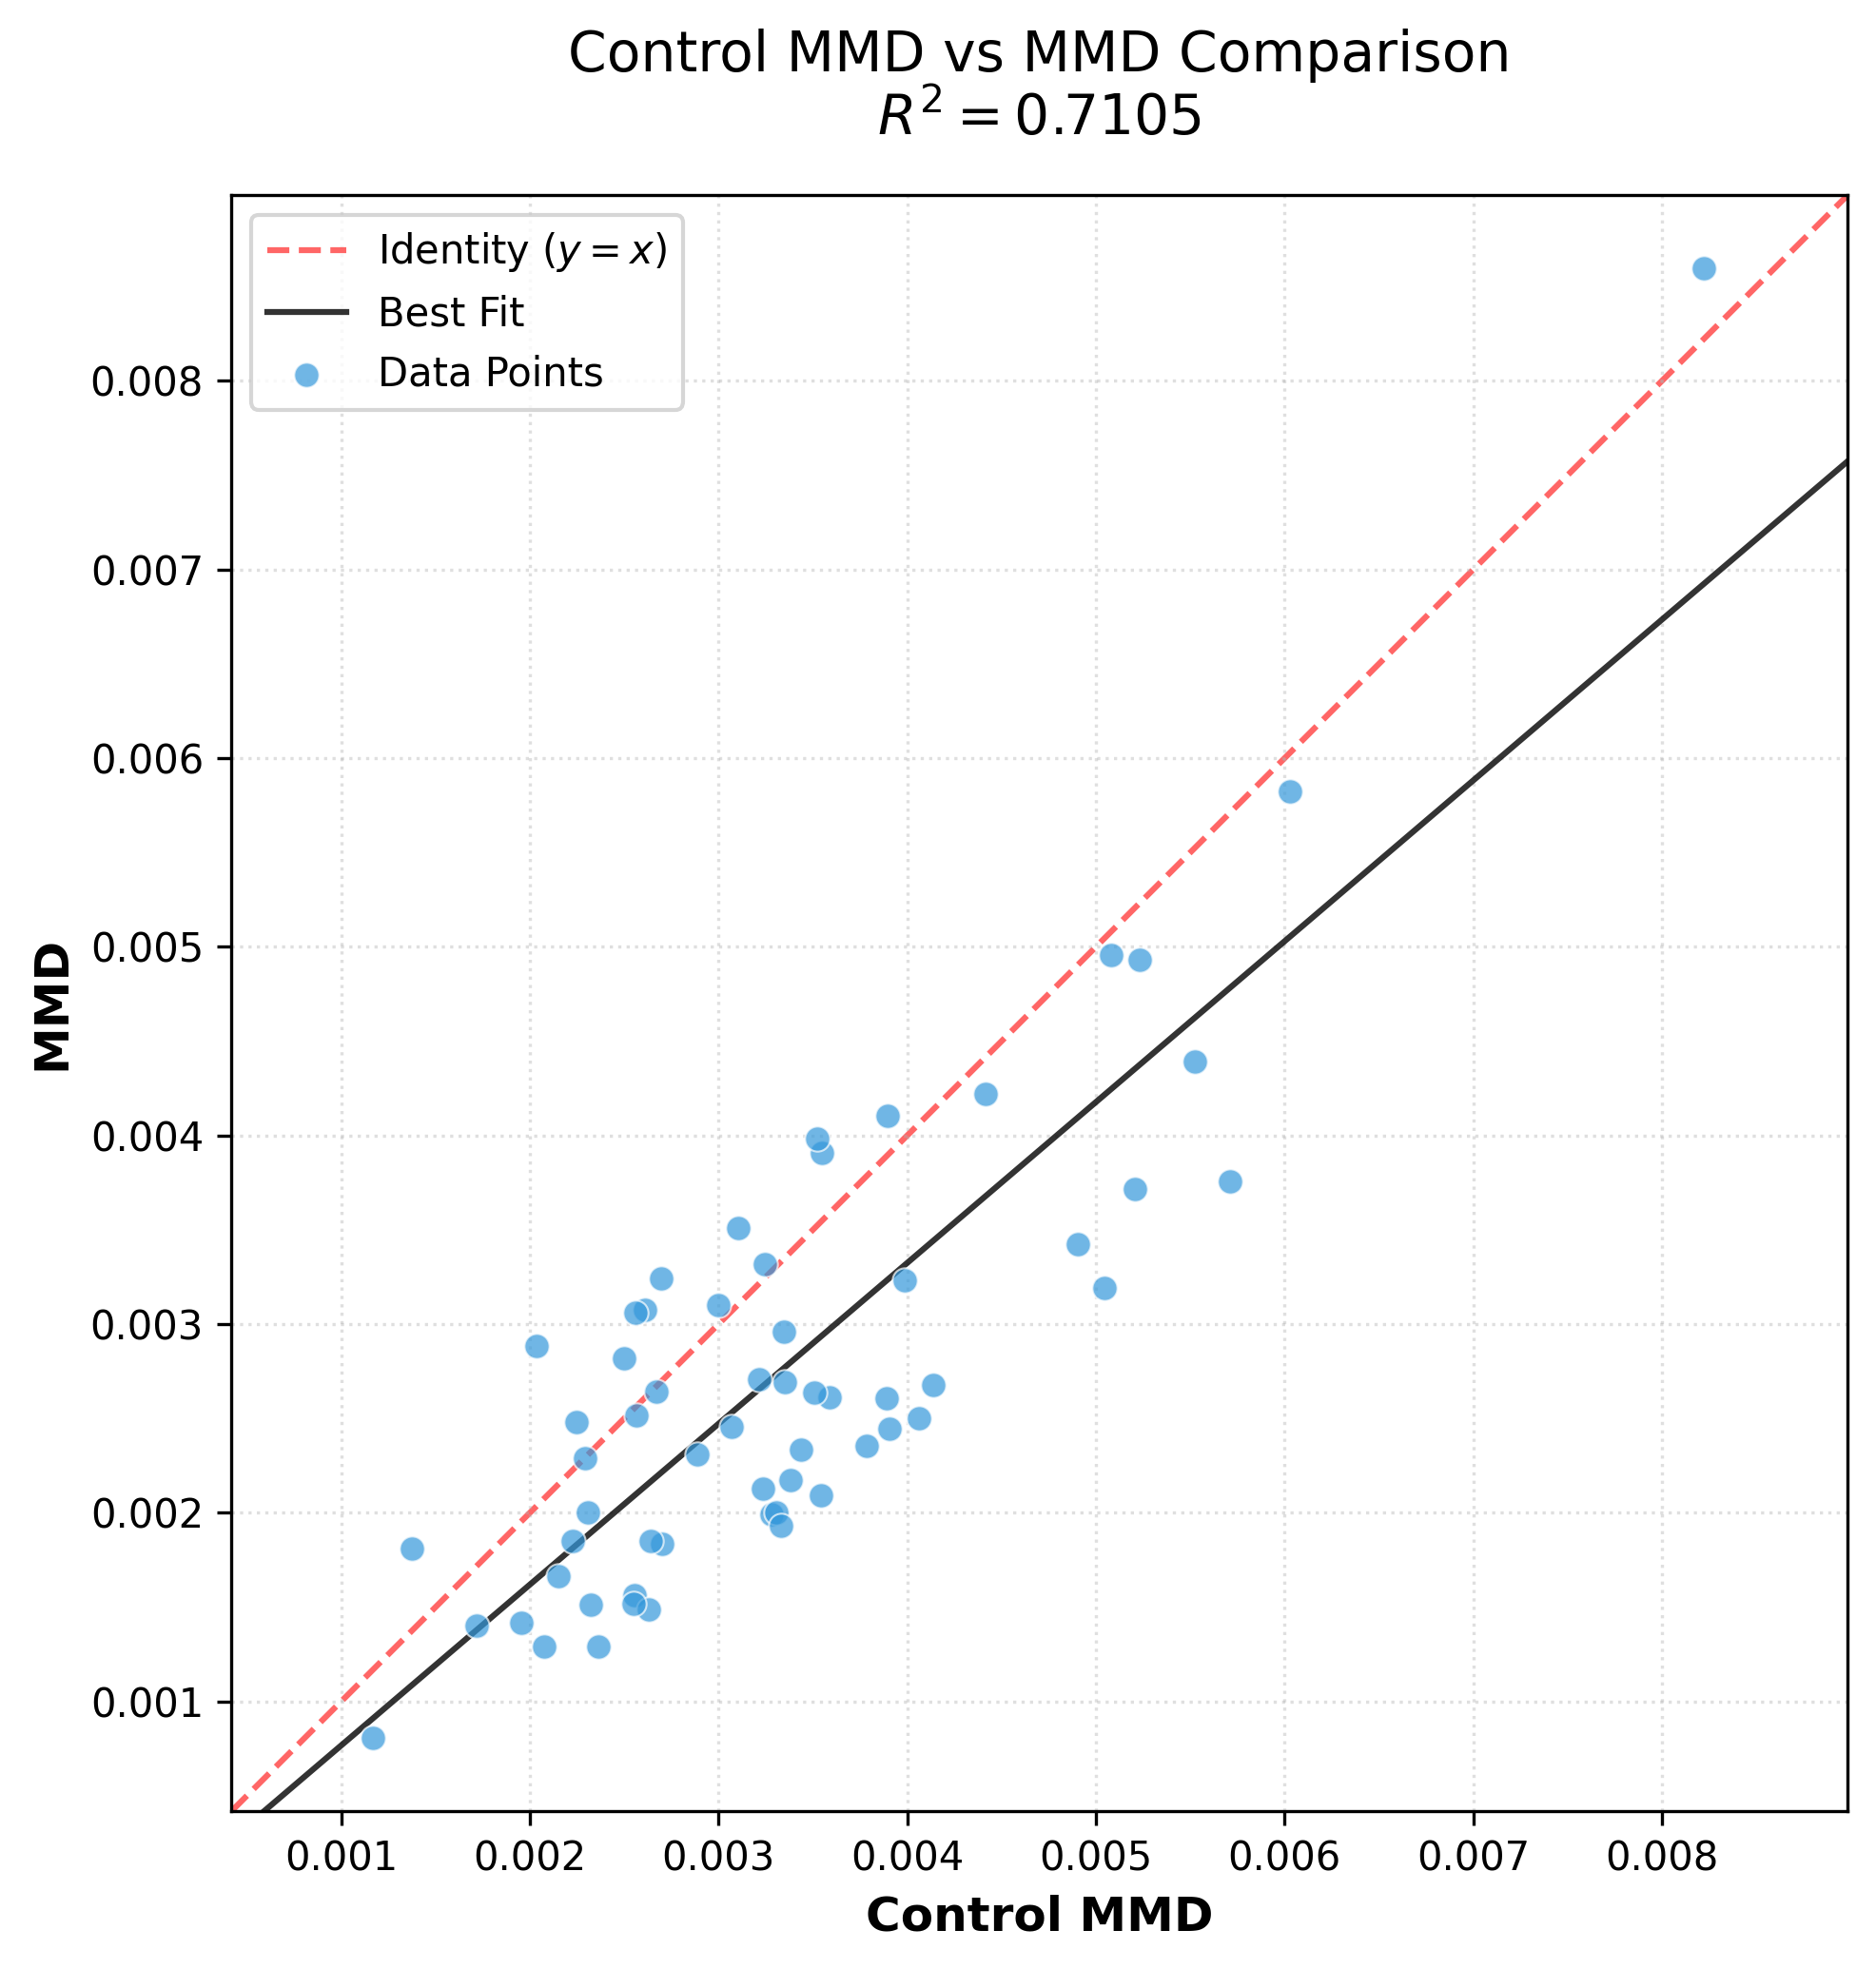

In [68]:
merged_df = pd.merge(df_filtered, df_random, on='drug_0')

x = merged_df['control_mmd']
y = merged_df['mmd']

# 2. Stats: R-squared and Regression line
slope, intercept, r_value, p_value, std_err = linregress(x, y)
r_squared = r_value**2

# 3. Calculate Limits with Padding
# Find the absolute min/max across both datasets for a square plot
data_min = min(x.min(), y.min())
data_max = max(x.max(), y.max())
data_range = data_max - data_min

padding = 0.05 * data_range  # 5% margin
plot_min = data_min - padding
plot_max = data_max + padding

# 4. Plotting
plt.figure(figsize=(7, 7), dpi=300)

# Identity Line (y=x) - Red, Dashed
plt.plot([plot_min, plot_max], [plot_min, plot_max], 
         color='red', linestyle='--', alpha=0.6, zorder=1, label='Identity ($y=x$)')

# Best Fit Line (Regression) - Black, Solid
reg_x = np.array([plot_min, plot_max])
reg_y = slope * reg_x + intercept
plt.plot(reg_x, reg_y, color='black', linewidth=1.5, alpha=0.8, zorder=2, label='Best Fit')

# Scatter Points
plt.scatter(x, y, s=40, alpha=0.7, edgecolors='white', linewidth=0.5, 
            color='#3498db', zorder=3, label='Data Points')

# 5. Apply the padded limits
plt.xlim(plot_min, plot_max)
plt.ylim(plot_min, plot_max)
plt.gca().set_aspect('equal', adjustable='box')

# Labels and Styling
plt.xlabel('Control MMD', fontsize=12, fontweight='bold')
plt.ylabel('MMD', fontsize=12, fontweight='bold')
plt.title(f'Control MMD vs MMD Comparison\n$R^2 = {r_squared:.4f}$', fontsize=14, pad=15)
plt.legend(loc='upper left', frameon=True, fontsize=10)
plt.grid(True, linestyle=':', alpha=0.4)

plt.tight_layout()

In [51]:
distances = pd.read_csv('/lustre/groups/ml01/workspace/alejandro.tejada/holdout_distances.csv', index_col=0)
distances

,L2,cosine,L1
condition,,,
Olanzapine|control,11.546742,3.683764e-01,62.050059
Aliskiren|control,12.421233,4.904784e-01,94.295169
Clotrimazole|control,8.514151,2.908528e-01,54.353202
Elagolix sodium|control,11.654591,4.243253e-01,97.430162
Ouabain (Octahydrate)|control,13.796584,2.803748e-01,104.241360
Pyridoxine (hydrochloride)|control,0.000000,0.000000e+00,0.000000
Pravastatin (sodium)|control,0.000000,0.000000e+00,0.000000
Entecavir (monohydrate)|control,6.862136,2.641269e-01,46.810435
Finasteride|control,7.349504,1.459021e-01,43.594391


In [52]:
distances['drug_0'] = distances.index.str.split('|').str[0]

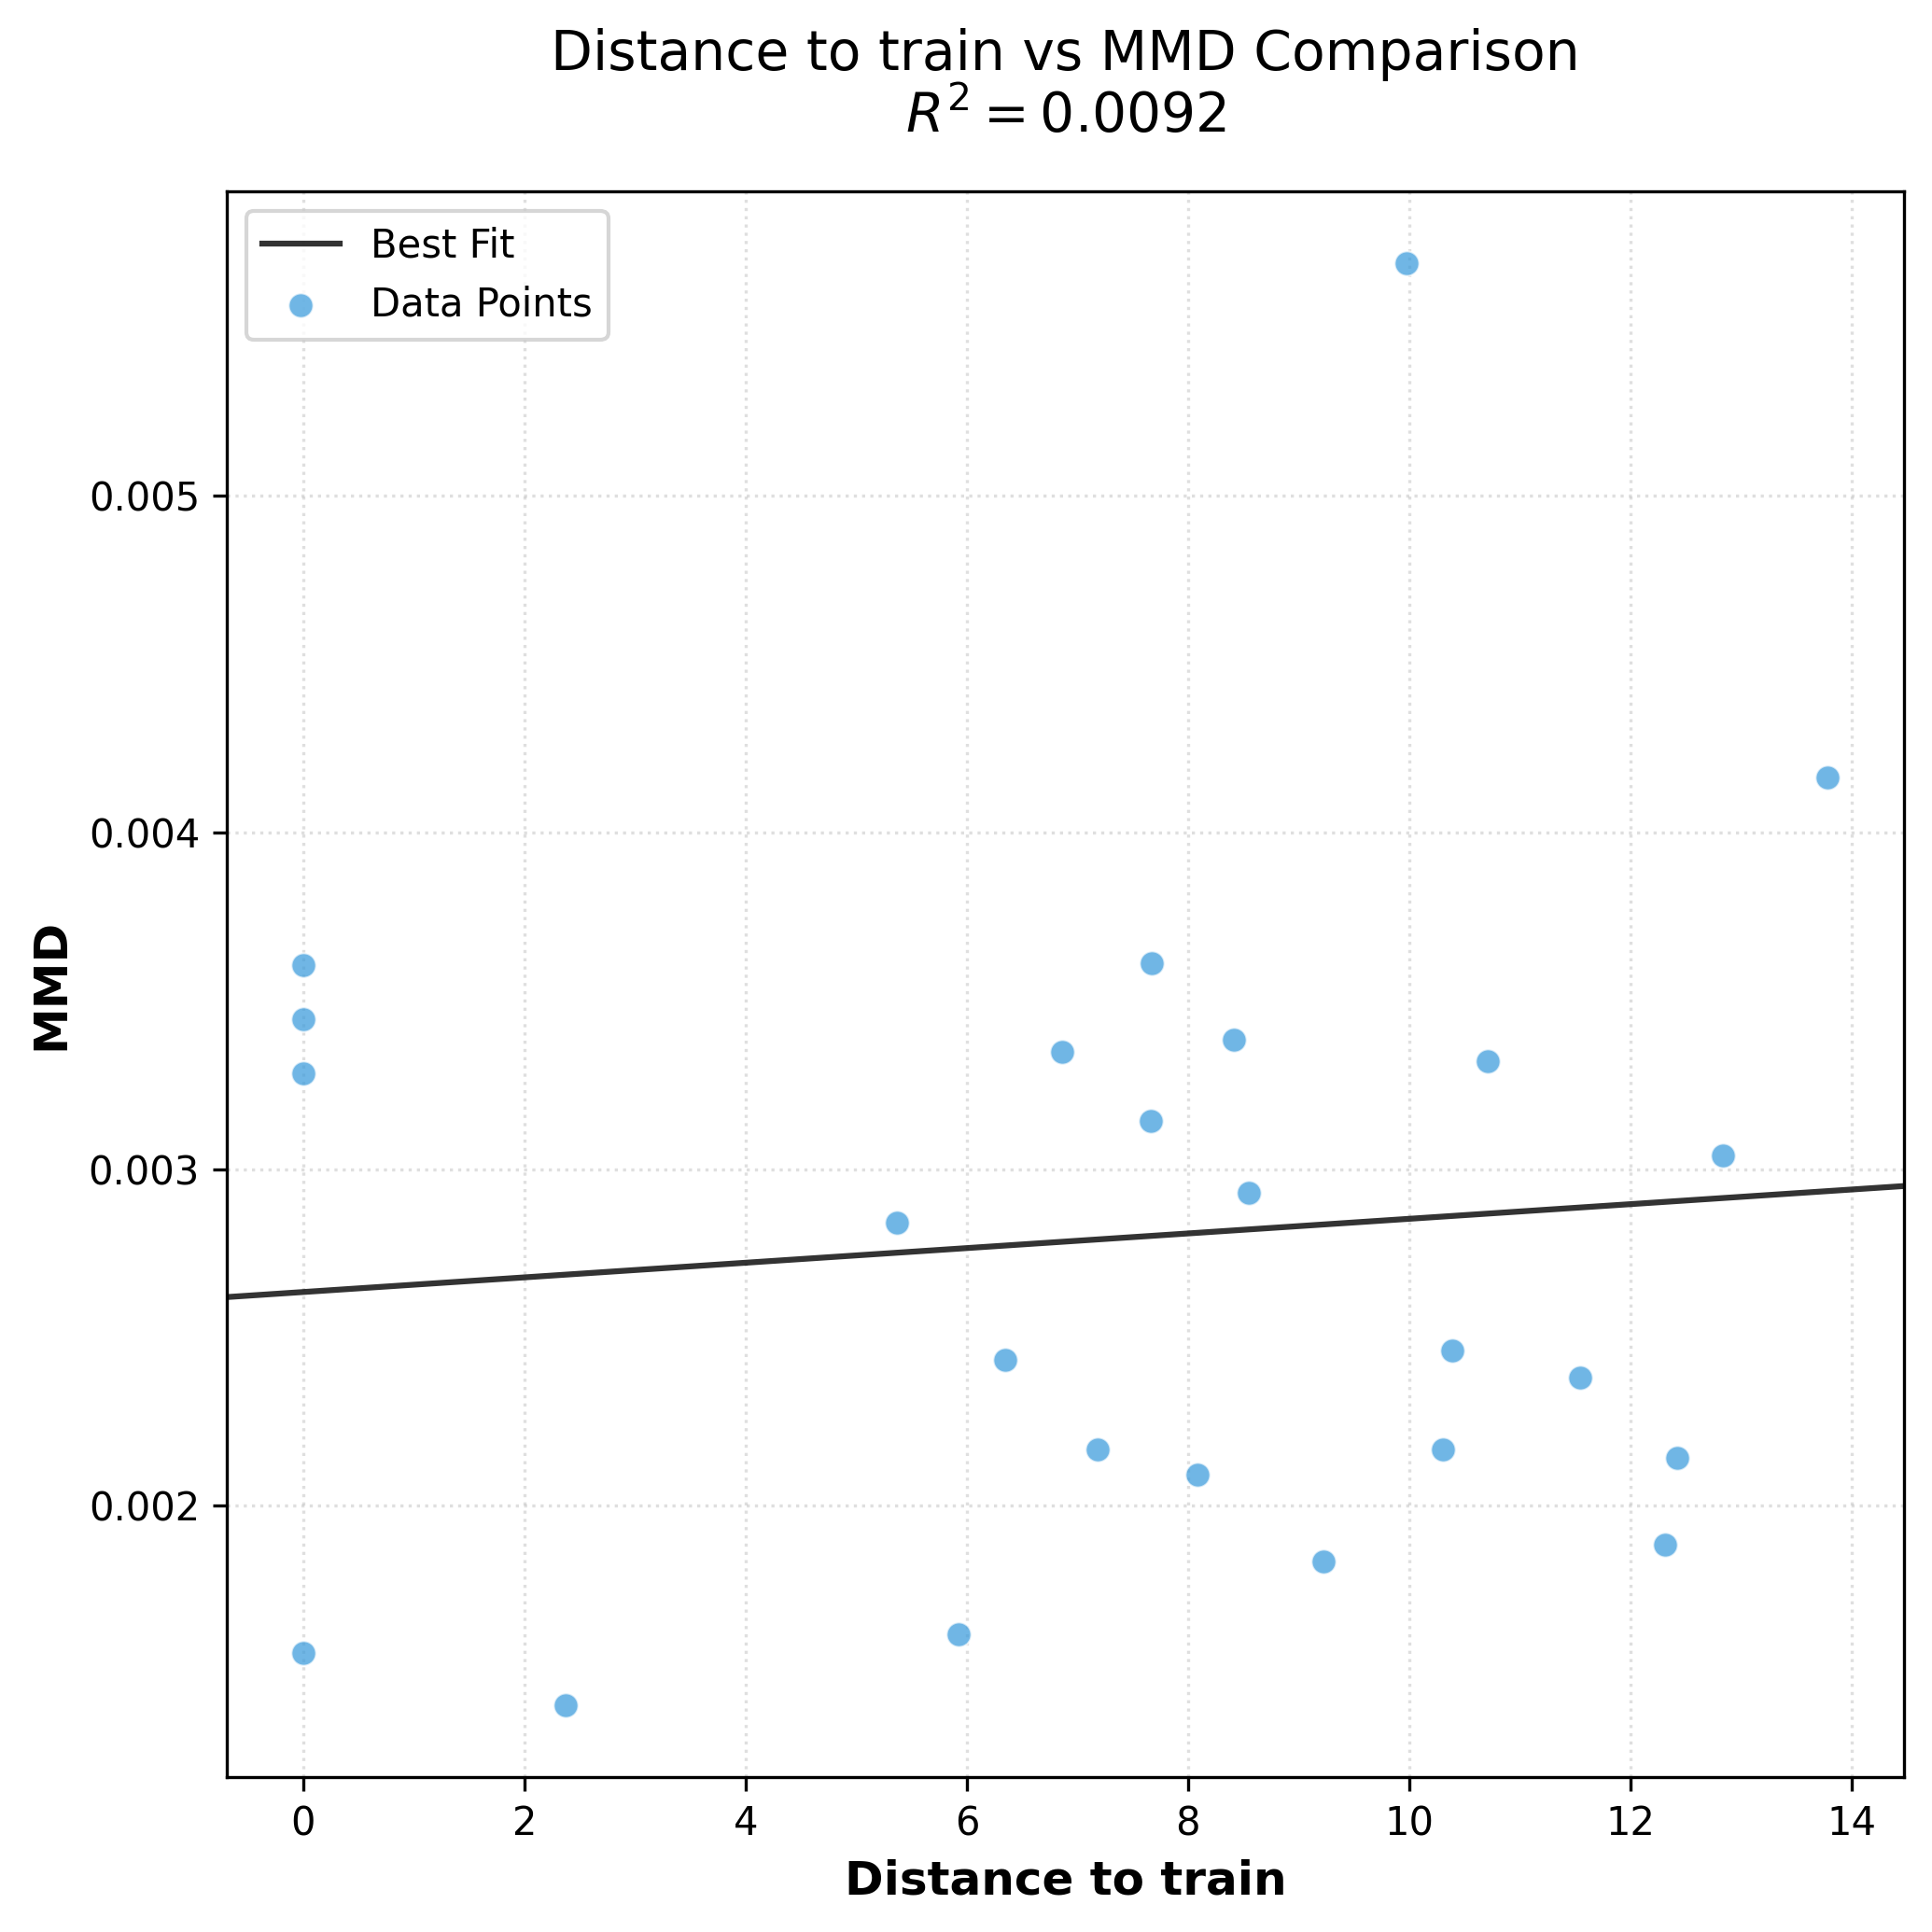

In [53]:
merged_df = pd.merge(distances, df_real, on='drug_0')

x = merged_df['L2']
y = merged_df['mmd']

slope, intercept, r_value, p_value, std_err = linregress(x, y)
r_squared = r_value**2

x_pad = 0.05 * (x.max() - x.min())
y_pad = 0.05 * (y.max() - y.min())

plt.figure(figsize=(7, 7), dpi=300)

reg_x = np.array([x.min() - x_pad, x.max() + x_pad])
reg_y = slope * reg_x + intercept
plt.plot(reg_x, reg_y, color='black', linewidth=1.5, alpha=0.8, zorder=2, label='Best Fit')

plt.scatter(x, y, s=40, alpha=0.7, edgecolors='white', linewidth=0.5,
            color='#3498db', zorder=3, label='Data Points')

plt.xlim(x.min() - x_pad, x.max() + x_pad)
plt.ylim(y.min() - y_pad, y.max() + y_pad)

plt.xlabel('Distance to train', fontsize=12, fontweight='bold')
plt.ylabel('MMD', fontsize=12, fontweight='bold')
plt.title(f'Distance to train vs MMD Comparison\n$R^2 = {r_squared:.4f}$', fontsize=14, pad=15)
plt.legend(loc='upper left', frameon=True, fontsize=10)
plt.grid(True, linestyle=':', alpha=0.4)

plt.tight_layout()

In [23]:
import pickle

In [24]:
emb_path = "/lustre/groups/ml01/workspace/xiaotong.fu/data/pancellflow/sup/drug_embeddings_256d.pkl"

# Open the file in 'rb' mode (read binary)
with open(emb_path, 'rb') as file:
    data = pickle.load(file)

In [26]:
adata = sc.read_h5ad('/lustre/groups/ml01/workspace/alejandro.tejada/tahoe_with_embeddings_normalized.h5ad')
adata

AnnData object with n_obs × n_vars = 2281500 × 62710
    obs: 'sample', 'species', 'gene_count', 'tscp_count', 'mread_count', 'bc1_wind', 'bc2_wind', 'bc3_wind', 'bc1_well', 'bc2_well', 'bc3_well', 'id', 'drugname_drugconc', 'drug', 'INT_ID', 'NUM.SNPS', 'NUM.READS', 'demuxlet_call', 'BEST.GUESS', 'BEST.LLK', 'NEXT.GUESS', 'NEXT.LLK', 'DIFF.LLK.BEST.NEXT', 'BEST.POSTERIOR', 'SNG.POSTERIOR', 'cell_line', 'SNG.BEST.LLK', 'SNG.NEXT.GUESS', 'SNG.NEXT.LLK', 'SNG.ONLY.POSTERIOR', 'DBL.BEST.GUESS', 'DBL.BEST.LLK', 'DIFF.LLK.SNG.DBL', 'sublibrary', 'BARCODE', 'pcnt_mito', 'S_score', 'G2M_score', 'phase', 'cell_line_orig', 'pass_filter', 'cell_name', 'dosage', 'plate', 'drug_0', 'drug_1', 'control'
    uns: 'cell_line_embeddings', 'drug_0_embeddings', 'drug_1_embeddings'
    obsm: 'X_state', 'X_state_scaled'

In [30]:
len(set(adata.uns['drug_0_embeddings'].keys()).intersection(data.keys()))

347

In [32]:
len(adata.uns['drug_0_embeddings'].keys())

360

### Plot also train

In [97]:
full_metrics = pd.read_csv('/lustre/groups/ml01/workspace/alejandro.tejada/train_and_predict/real_embeddings_film_otfm_unipert/metrics.csv')
full_metrics

,drug_0,cell_line,in_train,mmd,r_squared,e_distance,n_pred,n_tgt
0,4EGI-1,CVCL_0023,True,0.007591,0.961443,0.045383,57448,5687
1,5-Azacytidine,CVCL_0023,True,0.001253,0.994127,0.005910,57448,4901
2,5-Fluorouracil,CVCL_0023,True,0.001729,0.990993,0.009053,57448,5896
3,8-Hydroxyquinoline,CVCL_0023,True,0.002908,0.981435,0.019223,57448,7181
4,9-ING-41,CVCL_0023,True,0.002538,0.983232,0.016171,57448,6228
...,...,...,...,...,...,...,...,...
362,crizotinib,CVCL_0023,True,0.002744,0.985608,0.014843,57448,4593
363,olaparib,CVCL_0023,True,0.004494,0.976901,0.026122,57448,6824
364,palbociclib,CVCL_0023,True,0.003367,0.981676,0.019837,57448,4623
365,venetoclax,CVCL_0023,False,0.002708,0.984608,0.016075,57448,5720


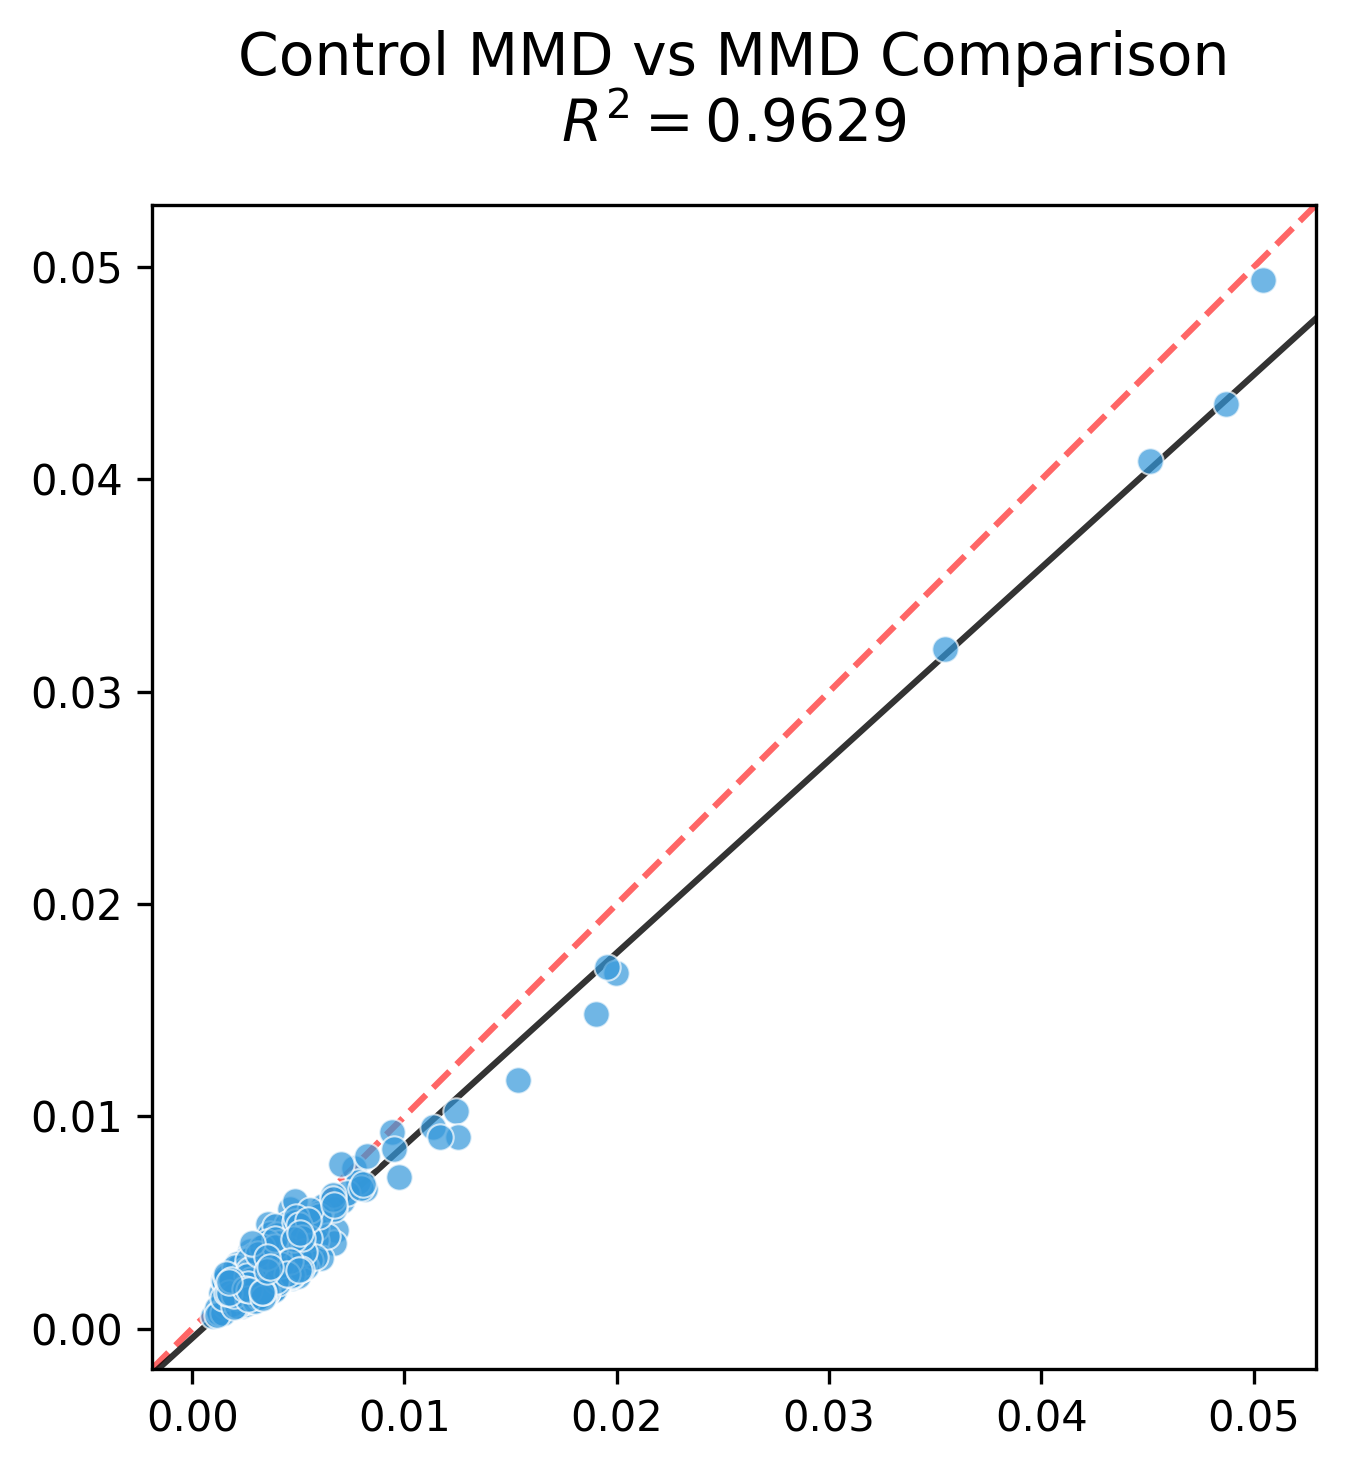

In [98]:
merged_df = pd.merge(df, full_metrics, on='drug_0')

x = merged_df['control_mmd']
y = merged_df['mmd']

# 2. Stats: R-squared and Regression line
slope, intercept, r_value, p_value, std_err = linregress(x, y)
r_squared = r_value**2

# 3. Calculate Limits with Padding
# Find the absolute min/max across both datasets for a square plot
data_min = min(x.min(), y.min())
data_max = max(x.max(), y.max())
data_range = data_max - data_min

padding = 0.05 * data_range  # 5% margin
plot_min = data_min - padding
plot_max = data_max + padding

# 4. Plotting
plt.figure(figsize=(5, 5), dpi=300)

# Identity Line (y=x) - Red, Dashed
plt.plot([plot_min, plot_max], [plot_min, plot_max], 
         color='red', linestyle='--', alpha=0.6, zorder=1, label='Identity ($y=x$)')

# Best Fit Line (Regression) - Black, Solid
reg_x = np.array([plot_min, plot_max])
reg_y = slope * reg_x + intercept
plt.plot(reg_x, reg_y, color='black', linewidth=1.5, alpha=0.8, zorder=2, label='Best Fit')

# Scatter Points
plt.scatter(x, y, s=40, alpha=0.7, edgecolors='white', linewidth=0.5, 
            color='#3498db', zorder=3, label='Data Points')

# 5. Apply the padded limits
plt.xlim(plot_min, plot_max)
plt.ylim(plot_min, plot_max)
plt.gca().set_aspect('equal', adjustable='box')

# Labels and Styling
# plt.xlabel('Control MMD', fontsize=12, fontweight='bold')
# plt.ylabel('MMD', fontsize=12, fontweight='bold')
plt.title(f'Control MMD vs MMD Comparison\n$R^2 = {r_squared:.4f}$', fontsize=14, pad=15)
# plt.legend(loc='upper left', frameon=True, fontsize=10)
# plt.grid(True, linestyle=':', alpha=0.4)

plt.tight_layout()